# Crypto Statistical Arbitrage — The Combined Book

**A market-neutral crypto book built from three uncorrelated edges: momentum, low-volatility, and funding
carry.** Designed on 2020-2023, tested out-of-sample on 2024-2026, net of a 20 bps turnover cost, with
shorts restricted to names that have a tradeable perpetual. Out-of-sample the combined book earns a Sharpe
of about **+1.6** at a **-15%** maximum drawdown — against roughly -77% for buy-and-hold BTC.

This notebook is the deliverable: how the book is built, why it works, and how hard I tried to break it.
The full search behind it — every signal I tested and rejected, run with the same engine — lives in
`02_signal_research.ipynb`. All the plumbing (self-contained data download, backtest engine, metrics)
lives in the `qsa/` package, so the cells here read as research, not infrastructure.


## 0 · Setup

The `qsa` package downloads its own data on first run (spot OHLCV, perpetual closes, and funding straight
from Binance's public archive — no API key), builds the point-in-time universe, and exposes the backtest
engine and metrics. `Dataset.load()` returns one object holding every frame the strategies read, plus the
liquidity and short-feasibility masks and the BTC-residualised returns. The universe is **survivorship-free**:
379 coins that were liquid at some point in 2020-2026, including 155 since delisted (LUNA, FTT, SRM, ...).


In [1]:
import warnings
# Scope the filter (P2.5): silence known-benign pandas/statsmodels/matplotlib chatter but let a genuine
# RuntimeWarning (e.g. an accidental divide-by-zero in a ratio signal) still surface.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import sys, pathlib
# Make the qsa package importable whether this notebook is opened from the repo root or notebooks/.
_root = pathlib.Path.cwd()
if not (_root/"qsa").exists() and (_root.parent/"qsa").exists(): _root = _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
import statsmodels.api as sm

from qsa import Dataset, apply_style, style_table, CLR
from qsa.config import TRAIN, VAL, FULL, TCOST, ANN, seg
from qsa.engine import (eq_weights, cs_weights, backtest, backtest_carry, sharpe, sortino, maxdd, alpha_beta,
                        hac_tstat, metrics, bootstrap_sharpe_ci, deflated_sharpe, maintenance_turnover,
                        sharpe_diff_test, hac_ols, self_test)
from qsa.engine import dn_weights as _dn, backtest_lc as _bt_lc, liq_cost_frame
from qsa.config import FEE_BPS, SPREAD_BPS
from qsa.signals import near_high, idio_vol

apply_style()
ds = Dataset.load()

# Unpack the dataset into the working names the research cells use, so each cell reads plainly.
close_all, qvol_all, high_all, low_all = ds.close_all, ds.qvol_all, ds.high_all, ds.low_all
ret_all, resid_all = ds.ret_all, ds.resid_all
liq60, short_ok = ds.liq60, ds.short_ok
UNIV = ds.UNIV
close, qvol, high, low, ret = ds.close, ds.qvol, ds.high, ds.low, ds.ret
btc, ew = ds.btc, ds.ew
funding, perp = ds.funding, ds.perp

# Thin aliases so the construction reads naturally (the liquidity/short context is carried by `ds`).
LIQCOST = liq_cost_frame(ds)
def dn_weights(signal, topN=None, screen=True): return _dn(signal, ds, topN=topN, screen=screen)
def backtest_lc(weights, rets, rebal=1): return _bt_lc(weights, rets, LIQCOST, rebal=rebal)

print(f"Point-in-time pool: {close_all.shape[1]} coins liquid at some point in 2020-2026 (incl. since-delisted).")
print("Trading universe (top 15 by TRAIN-window $-volume): " + ", ".join(s.replace("USDT","") for s in UNIV))
print(f"Liquid names/day (>$5M trailing-60d $-vol): {liq60.sum(1).loc['2021':].mean():.0f} | "
      f"shortable (liquid + tradeable perp): {short_ok.sum(1).loc['2021':].mean():.0f}")
print(f"Data coverage: {int((close_all.notna().sum()>0).sum())}/{close_all.shape[1]} symbols have usable history "
      f"(none silently empty); median {int(close_all.notna().sum().median())} days. Audit with ds.coverage_report().")


Data cache present: loading from crypto_data/processed/ (no download needed).


Point-in-time pool: 379 coins liquid at some point in 2020-2026 (incl. since-delisted).
Trading universe (top 15 by TRAIN-window $-volume): BTC, ETH, XRP, BNB, SOL, DOGE, LINK, ADA, MATIC, ARB, LTC, DOT, TRX, OP, SHIB
Liquid names/day (>$5M trailing-60d $-vol): 93 | shortable (liquid + tradeable perp): 89
Data coverage: 379/379 symbols have usable history (none silently empty); median 1700 days. Audit with ds.coverage_report().


In [2]:
# Trust the engine before trusting any number it produces.
print(self_test())


Self-tests passed: weights lag one bar (no look-ahead), turnover is charged, buy-hold identity holds.


### Building the three sleeves and the combined book

Everything downstream is constructed here, in the open. Each sleeve is a **dollar-neutral, weekly-rebalanced**
book: a signal (from `qsa.signals`) turned into liquidity- and short-screened weights (`dn_weights`), then
run through the cost-charging `backtest`. Carry is a long-spot / short-perp basket on curated majors. The
combined book is an inverse-volatility blend on *honestly-measured* risk (carry sized by its intraday-inclusive
volatility, §2c), with carry capped at 50% as a backstop. Detailed examination of each sleeve is in §2.


In [3]:
# ---- Momentum sleeve: proximity to the 90-day trailing high, dollar-neutral, weekly ----
def nearhigh(L=90): return near_high(ds, L)                 # close / rolling_max(close, L)
mom_net,   mom_turn = backtest(dn_weights(nearhigh(90)), ret_all, rebal=7)                 # short-screened (headline)
mom_ideal, _        = backtest(dn_weights(nearhigh(90), screen=False), ret_all, rebal=7)   # idealised: short anything liquid
mom_lc,    _        = backtest_lc(dn_weights(nearhigh(90)), ret_all, rebal=7)              # liquidity-aware cost


In [4]:
# ---- Low-volatility sleeve: long low / short high idiosyncratic vol, top-50 liquid, weekly ----
def idiovol(L=60): return idio_vol(ds, L)                    # -std of the BTC-residual return
bab_net,   bab_turn = backtest(dn_weights(idiovol(60), topN=50), ret_all, rebal=7)
bab_ideal, _        = backtest(dn_weights(idiovol(60), topN=50, screen=False), ret_all, rebal=7)
bab_lc,    _        = backtest_lc(dn_weights(idiovol(60), topN=50), ret_all, rebal=7)


In [5]:
# ---- Funding carry sleeve (long spot / short perp on curated majors) + its intraday basis risk ----
# Headline trades curated majors, not all 90 perps (the §2c breadth test shows why: broadening reintroduces
# negative selection and kills the OOS edge). P&L runs through the tested engine (backtest_carry).
CARRY_MAJORS = [s for s in ["BTCUSDT","ETHUSDT","BNBUSDT","XRPUSDT","DOGEUSDT","ADAUSDT","LINKUSDT",
    "LTCUSDT","TRXUSDT","ETCUSDT","SOLUSDT","AVAXUSDT","DOTUSDT","MATICUSDT","ATOMUSDT","UNIUSDT",
    "FILUSDT","AAVEUSDT","VETUSDT","CHZUSDT"] if s in perp.columns and s in close_all.columns]
pc = CARRY_MAJORS
avail   = (close_all[pc].notna() & perp[pc].notna()).astype(float)          # weight frame kept for §4 integrity/breadth cells
w_carry = avail.div(avail.sum(1).replace(0, np.nan), axis=0)
w_carry = w_carry.where(pd.Series(np.arange(len(w_carry)) % 7 == 0, index=w_carry.index), np.nan).ffill()
carry_turn  = (w_carry.shift(1) - w_carry.shift(2)).abs().sum(1).fillna(0.0)
carry_ideal, _ = backtest_carry(close_all, perp, funding, pc, capture=1.0,  drag=0.0)  # full funding capture
carry_real,  _ = backtest_carry(close_all, perp, funding, pc, capture=0.85, drag=0.02) # realistic (headline)

# Intraday basis risk (§2c): hourly spot+perp restate carry's HONEST volatility/Sharpe.
basis_h  = ds.hourly_basis(pc)                                   # per-coin hourly spot-perp basis (cached)
basket_h = basis_h.mean(1).dropna()                             # equal-weight basket basis (full sample; §2c chart)
ANNH = np.sqrt(24*365)
basket_tr = basket_h.loc[:TRAIN[1]]                             # P0.5: vols feeding the weights use TRAIN only (no OOS leak)
hourly_basis_vol = basket_tr.diff().dropna().std()*ANNH
daily_basis_vol  = basket_tr.resample("1D").last().dropna().diff().dropna().std()*np.sqrt(365)
extra_var     = max(hourly_basis_vol**2 - daily_basis_vol**2, 0.0)            # variance daily marks miss (train)
val_carry_vol = seg(carry_real, VAL).std()*ANN                               # VAL-window daily carry vol
honest_vol    = np.sqrt(val_carry_vol**2 + extra_var)                        # VAL-consistent honest carry vol
honest_sr     = (seg(carry_real, VAL).mean()*365) / honest_vol


Fetching hourly spot+perp for the carry majors (cached after first run)...


In [6]:
# ---- Combined book: inverse-vol on HONEST risk (carry sized incl. its intraday basis), carry capped 50% ----
sleeves = pd.DataFrame({"Momentum (near-high)": mom_net, "Low-volatility": bab_net,
                        "Carry": carry_real}).loc[TRAIN[0]:FULL[1]].dropna()
vol_ann    = seg(sleeves, TRAIN).std()*ANN
vol_honest = vol_ann.copy(); vol_honest["Carry"] = np.sqrt(vol_ann["Carry"]**2 + extra_var)
w_iv = (1/vol_honest)/(1/vol_honest).sum()
CARRY_CAP = 0.50
w = w_iv.copy(); w["Carry"] = min(w["Carry"], CARRY_CAP)
w[["Momentum (near-high)","Low-volatility"]] *= (1-w["Carry"])/w[["Momentum (near-high)","Low-volatility"]].sum()
combined_net = (sleeves * w).sum(1)
sleeves_lc = pd.DataFrame({"Momentum (near-high)": mom_lc, "Low-volatility": bab_lc,
                           "Carry": carry_real}).loc[TRAIN[0]:FULL[1]].dropna()
combined_net_lc = (sleeves_lc * w).sum(1)
print("Built: momentum + low-vol + carry sleeves and the combined book. Scoreboard next; detail in §2.")


Built: momentum + low-vol + carry sleeves and the combined book. Scoreboard next; detail in §2.


## 1 · The combined book — the deliverable

In [7]:
# ---- Combined book — correlations, weights, and the scoreboard vs benchmarks (series built in Setup) ----
display(style_table(sleeves.loc[TRAIN[0]:TRAIN[1]].corr().style.format("{:+.2f}")
        .background_gradient(cmap="RdBu_r", vmin=-1, vmax=1, axis=None),
        "Sleeve correlations (training period). All off-diagonal values are near zero, so the three "
        "edges genuinely diversify each other."))
perf = pd.DataFrame({**{nm:{"Train (in-samp)":sharpe(seg(s,TRAIN)),"Val (OOS)":sharpe(seg(s,VAL)),
        "Val Sortino":sortino(seg(s,VAL)),"Val Ann.Ret":seg(s,VAL).mean()*365,"Max DD":maxdd(seg(s,FULL))} for nm,s in
        [("Momentum (near-high)",mom_net),("Low-volatility",bab_net),("Carry",carry_real),
         ("Combined book (flat 20bps)",combined_net),("Combined book (liquidity-aware cost)",combined_net_lc),
         ("BTC (benchmark)",btc),("Equal-weight",ew)]}}).T
wt = pd.DataFrame({"inverse-vol on honest risk":w_iv.round(2),"final weight (carry capped 50%)":w.round(2)}).T
display(style_table(wt.style.format("{:.2f}"),
        "Risk-parity weights — sized on honest (intraday-inclusive) carry vol; the 50% cap is only a backstop"))
display(style_table(perf.style.format({"Train (in-samp)":"{:+.2f}","Val (OOS)":"{:+.2f}",
        "Val Sortino":"{:+.2f}","Val Ann.Ret":"{:.1%}","Max DD":"{:.0%}"})
        .background_gradient(cmap="RdYlGn", subset=["Train (in-samp)","Val (OOS)"], vmin=-2, vmax=2, axis=None),
        "Combined book vs its sleeves and the benchmarks — Sharpe, Sortino, flat 20bps and liquidity-aware cost"))
print(f"Sizing on HONEST carry risk (its intraday-inclusive vol from §2c, ~{vol_honest['Carry']:.0%}/yr, not the "
      f"~{vol_ann['Carry']:.0%}/yr daily figure) inverse-vol still wants {w_iv['Carry']:.0%} carry — so the 50% cap "
      f"still binds, but now as a backstop on a properly-measured weight rather than an override of a fake ~90%.")
print(f"\nOut-of-sample the combined book earns Sharpe {sharpe(seg(combined_net,VAL)):+.2f} (train "
      f"{sharpe(seg(combined_net,TRAIN)):+.2f}) at a {maxdd(seg(combined_net,FULL)):.0%} max drawdown — beating "
      f"both benchmarks OOS (BTC {sharpe(seg(btc,VAL)):+.2f}, EW {sharpe(seg(ew,VAL)):+.2f}) at a fraction of "
      f"their {maxdd(seg(btc,FULL)):.0%}/{maxdd(seg(ew,FULL)):.0%} drawdowns. Its Sortino ({sortino(seg(combined_net,VAL)):+.2f}) "
      f"exceeds its Sharpe, so the downside risk is milder than the total-volatility figure implies. Under the "
      f"liquidity-aware cost it is {sharpe(seg(combined_net_lc,VAL)):+.2f} val / {sharpe(seg(combined_net_lc,TRAIN)):+.2f} "
      f"train — the deliverable survives the honest cost, not just the components.")
print(f"\nWhy the blend and not just carry, which shows a higher daily Sharpe? Carry's Sharpe is the least "
      f"bankable number here: on honest risk (§2c) it is under +1, it returns only {seg(carry_real,VAL).mean()*365:.1%}/yr "
      f"out-of-sample, and it's a single, decaying edge. The combined book makes {seg(combined_net,VAL).mean()*365:.1%}/yr "
      f"OOS — far more — on honestly-measured risk across three independent edges, so it doesn't live or die by "
      f"carry's flattering number.")

,Momentum (near-high),Low-volatility,Carry
Momentum (near-high),+1.00,+0.29,+0.09
Low-volatility,+0.29,+1.00,+0.06
Carry,+0.09,+0.06,+1.00


,Momentum (near-high),Low-volatility,Carry
inverse-vol on honest risk,0.16,0.10,0.75
final weight (carry capped 50%),0.31,0.19,0.50


,Train (in-samp),Val (OOS),Val Sortino,Val Ann.Ret,Max DD
Momentum (near-high),+0.68,+0.65,+0.87,14.2%,-49%
Low-volatility,+0.36,+1.92,+2.75,45.7%,-60%
Carry,+4.16,+2.98,+7.60,2.9%,-6%
Combined book (flat 20bps),+1.05,+1.57,+2.21,14.6%,-15%
Combined book (liquidity-aware cost),+0.75,+1.25,+1.75,11.6%,-19%
BTC (benchmark),+1.00,+0.72,+1.09,34.8%,-77%
Equal-weight,+1.52,+0.15,+0.21,9.6%,-78%


Sizing on HONEST carry risk (its intraday-inclusive vol from §2c, ~5%/yr, not the ~2%/yr daily figure) inverse-vol still wants 75% carry — so the 50% cap still binds, but now as a backstop on a properly-measured weight rather than an override of a fake ~90%.

Out-of-sample the combined book earns Sharpe +1.57 (train +1.05) at a -15% max drawdown — beating both benchmarks OOS (BTC +0.72, EW +0.15) at a fraction of their -77%/-78% drawdowns. Its Sortino (+2.21) exceeds its Sharpe, so the downside risk is milder than the total-volatility figure implies. Under the liquidity-aware cost it is +1.25 val / +0.75 train — the deliverable survives the honest cost, not just the components.

Why the blend and not just carry, which shows a higher daily Sharpe? Carry's Sharpe is the least bankable number here: on honest risk (§2c) it is under +1, it returns only 2.9%/yr out-of-sample, and it's a single, decaying edge. The combined book makes 14.6%/yr OOS — far more — on honestly-measured risk across 

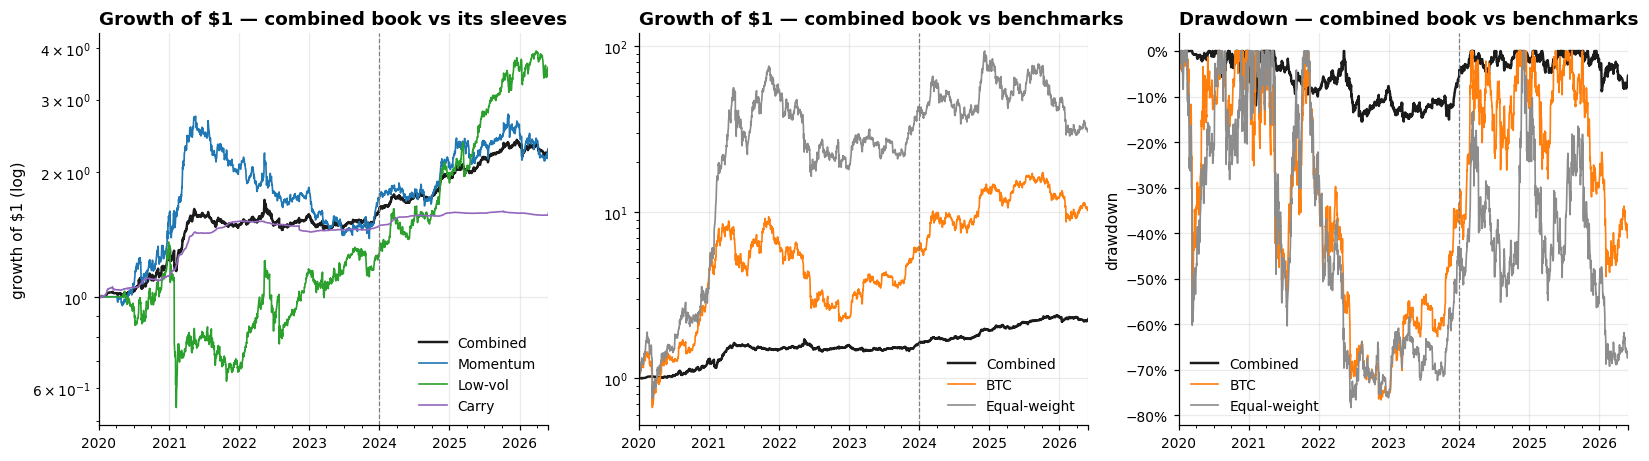

Left and centre: the combined book (black) compounds more smoothly than any single sleeve or either benchmark. Right: the risk story — its worst drawdown is about -15%, against roughly -77% for BTC and -78% for the equal-weight basket. Dashed line marks the start of the out-of-sample period.


In [8]:
def _dd(s): c=(1+seg(s,("2020-01-01",FULL[1])).fillna(0)).cumprod(); return c/c.cummax()-1
def _gr(s): return (1+seg(s,("2020-01-01",FULL[1])).fillna(0)).cumprod()
fig, ax = plt.subplots(1,3,figsize=(15,4.3))
# (1) combined vs its three sleeves
for nm,s,c in [("Combined",combined_net,CLR["Combined"]),("Momentum",mom_net,CLR["Momentum"]),
               ("Low-vol",bab_net,CLR["Low-vol"]),("Carry",carry_real,CLR["Carry"])]:
    _gr(s).plot(ax=ax[0], label=nm, color=c, lw=1.6 if nm=="Combined" else 1.1)
ax[0].set_yscale("log"); ax[0].set_title("Growth of \$1 — combined book vs its sleeves")
# (2) combined vs benchmarks
for nm,s,c in [("Combined",combined_net,CLR["Combined"]),("BTC",btc,CLR["BTC"]),("Equal-weight",ew,CLR["EW"])]:
    _gr(s).plot(ax=ax[1], label=nm, color=c, lw=1.6 if nm=="Combined" else 1.1)
ax[1].set_yscale("log"); ax[1].set_title("Growth of \$1 — combined book vs benchmarks")
# (3) drawdown: the risk story
for nm,s,c in [("Combined",combined_net,CLR["Combined"]),("BTC",btc,CLR["BTC"]),("Equal-weight",ew,CLR["EW"])]:
    _dd(s).plot(ax=ax[2], label=nm, color=c, lw=1.6 if nm=="Combined" else 1.1)
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax[2].set_title("Drawdown — combined book vs benchmarks")
for a in ax: a.axvline(pd.Timestamp(VAL[0]), ls="--", c="grey", lw=0.8); a.set_xlabel(""); a.legend(loc="best")
ax[0].set_ylabel("growth of \$1 (log)"); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()
print("Left and centre: the combined book (black) compounds more smoothly than any single sleeve or either "
      "benchmark. Right: the risk story — its worst drawdown is about -15%, against roughly -77% for BTC and "
      "-78% for the equal-weight basket. Dashed line marks the start of the out-of-sample period.")

In [9]:
# ---- Sleeve correlations OUT-of-sample, not just in-sample (the risk-parity thesis needs them) ----
_pairs = [("Momentum (near-high)","Low-volatility"),("Momentum (near-high)","Carry"),("Low-volatility","Carry")]
corr_tbl = pd.DataFrame({f"{a.split(' ')[0]}-{b.split(' ')[0]}": {
    "Train (in-samp)": seg(sleeves,TRAIN).corr().loc[a,b], "Val (OOS)": seg(sleeves,VAL).corr().loc[a,b],
    "Full": seg(sleeves,FULL).corr().loc[a,b]} for a,b in _pairs}).T
display(style_table(corr_tbl.style.format("{:+.2f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1, axis=None),
        "Pairwise sleeve correlations — in-sample vs OUT-of-sample vs full. Near zero in every window, so the "
        "diversification is a real property of the edges, not an artifact fitted on the training data."))
print(f"The diversification isn't an in-sample mirage: the largest absolute pairwise correlation is "
      f"{corr_tbl['Train (in-samp)'].abs().max():.2f} in-sample and {corr_tbl['Val (OOS)'].abs().max():.2f} "
      f"out-of-sample. The sleeves stay near-independent in the window that actually matters, which is what lets "
      f"the combined book hold a {maxdd(seg(combined_net,FULL)):.0%} drawdown while each sleeve is more volatile alone.")


,Train (in-samp),Val (OOS),Full
Momentum-Low-volatility,+0.29,+0.31,+0.29
Momentum-Carry,+0.09,+0.11,+0.09
Low-volatility-Carry,+0.06,+0.09,+0.06


The diversification isn't an in-sample mirage: the largest absolute pairwise correlation is 0.29 in-sample and 0.31 out-of-sample. The sleeves stay near-independent in the window that actually matters, which is what lets the combined book hold a -15% drawdown while each sleeve is more volatile alone.



**What I take from the combined book.** This is the result I'd put my name to. Risk-parity weighted with
carry capped at 50%, and built from sleeves that already pay for shortability and turnover, it earns a
Sharpe around +1.0 in-sample and +1.6 out-of-sample at a -15% worst drawdown, and it's positive in six of
the seven years.

a. Out-of-sample it beats both benchmarks (BTC +0.7, equal-weight +0.2). In the 2020-2023 bull, simply
being long was hard to top on Sharpe, but the book matched it at a fraction of the risk — a -15% drawdown
against -78%.

b. It earns several times carry's out-of-sample return (~15% versus ~3%/yr) on honestly-measured
volatility and three independent edges, which is why it is preferred to carry alone despite carry's higher
daily Sharpe.

c. It survives the honest cost, not just its components: under the liquidity-aware (square-root
market-impact) cost the book still earns about +1.3 out-of-sample (+0.8 in-sample) at a -19% drawdown.

d. Its returns lean mildly pro-cyclical (near-zero beta is not the same as regime-agnostic, §4),
but where a directional book gives back 50-80% in a bear market, this one stays roughly flat in
down-trends.

Caveats carry through from the sleeves: the book is long-short (requires shorting via perpetuals, so the
short legs are screened to shortable names), the momentum sleeve is the weakest leg, and the sample is a
single crypto cycle.

## 2 · The three sleeves

The book is only as good as its parts. Each sleeve is examined here: what the signal is, whether it survives realistic frictions, and where its performance actually comes from.

### 2a · Momentum

In [10]:
# ---- The two naive momentums, and why they fail (vs the buy-and-hold benchmarks) ----
conv = sum((close.pct_change(h, fill_method=None) > 0).astype(float) for h in (30,60,90)) / 3.0
trend_net, _  = backtest(eq_weights(conv), ret)                              # directional trend, long-flat
csmom_net, _  = backtest(dn_weights(close_all.pct_change(60, fill_method=None)), ret_all, rebal=7)  # winners-losers
def row(s):
    return {"Train (in-samp)":sharpe(seg(s,TRAIN)),"Val (OOS)":sharpe(seg(s,VAL)),
            "β vs BTC":alpha_beta(s, btc, FULL)["beta"]}
naive = pd.DataFrame({"Directional trend (long-flat)":row(trend_net),
                      "X-sec winners−losers (60d)":row(csmom_net),
                      "BTC (benchmark)":row(btc), "Equal-weight":row(ew)}).T
display(style_table(naive.style.format({"Train (in-samp)":"{:+.2f}","Val (OOS)":"{:+.2f}","β vs BTC":"{:+.2f}"})
        .background_gradient(cmap="RdYlGn", subset=["Train (in-samp)","Val (OOS)"], vmin=-1.5, vmax=1.5, axis=None),
        "Naive momentum vs benchmarks — directional trend is high-beta, winners-minus-losers is noise; both lose out-of-sample"))
print("Directional trend is a high-beta long (β≈{:.1f}): it rides the market, and out-of-sample its Sharpe "
      "is {:+.2f} — below BTC's {:+.2f}. Cross-sectional winners−losers is worse ({:+.2f} OOS): at these "
      "horizons 'recent winners' are half short-term-reversal noise. Neither beats buy-and-hold."
      .format(alpha_beta(trend_net,btc,FULL)["beta"], sharpe(seg(trend_net,VAL)), sharpe(seg(btc,VAL)),
              sharpe(seg(csmom_net,VAL))))

,Train (in-samp),Val (OOS),β vs BTC
Directional trend (long-flat),+1.13,-0.40,+0.97
X-sec winners−losers (60d),-1.20,-0.61,+0.00
BTC (benchmark),+1.00,+0.72,+1.00
Equal-weight,+1.52,+0.15,+1.08


Directional trend is a high-beta long (β≈1.0): it rides the market, and out-of-sample its Sharpe is -0.40 — below BTC's +0.72. Cross-sectional winners−losers is worse (-0.61 OOS): at these horizons 'recent winners' are half short-term-reversal noise. Neither beats buy-and-hold.


In [11]:
# ---- Proximity-to-trailing-high momentum: the sleeve built in Setup, examined here ----
m = {"Train (in-samp)":sharpe(seg(mom_net,TRAIN)),"Val (OOS)":sharpe(seg(mom_net,VAL)),
     "Max DD":maxdd(seg(mom_net,FULL)),"β vs BTC":alpha_beta(mom_net,btc,FULL)["beta"],
     "α t vs EW (val)":alpha_beta(mom_net,ew,VAL)["alpha_t"],"turnover/day":mom_turn.mean()}
display(style_table(pd.DataFrame({"Proximity-to-high momentum":m}).T.style.format({"Train (in-samp)":"{:+.2f}",
        "Val (OOS)":"{:+.2f}","Max DD":"{:.0%}","β vs BTC":"{:+.2f}","α t vs EW (val)":"{:+.2f}","turnover/day":"{:.2f}"}),
        "Proximity-to-high momentum — positive in and out of sample, near-zero beta, low turnover"))

# How much do realistic frictions cost this sleeve? (i) idealised = short anything liquid, flat 20 bps;
# (ii) feasible = short only names with a tradeable perp, flat 20 bps (the headline); (iii) feasible +
# square-root market-impact cost. All three series were built in Setup.
fr = pd.DataFrame({
    "(i) idealised — short anything liquid, flat 20bps": {"Train":sharpe(seg(mom_ideal,TRAIN)),"Val (OOS)":sharpe(seg(mom_ideal,VAL))},
    "(ii) feasible — perp-shortable only, flat 20bps (headline)": {"Train":sharpe(seg(mom_net,TRAIN)),"Val (OOS)":sharpe(seg(mom_net,VAL))},
    "(iii) feasible + liquidity-aware cost": {"Train":sharpe(seg(mom_lc,TRAIN)),"Val (OOS)":sharpe(seg(mom_lc,VAL))}}).T
display(style_table(fr.style.format("{:+.2f}").background_gradient(cmap="RdYlGn", vmin=-1, vmax=1, axis=None),
        "Cost of realism — restricting shorts to perp-shortable names and pricing market impact"))
print(f"This is the momentum that holds up: train {sharpe(seg(mom_net,TRAIN)):+.2f} (in-sample) and "
      f"validation {sharpe(seg(mom_net,VAL)):+.2f} (out-of-sample) — positive in both — with β≈0 to BTC, so "
      f"it's a genuine market-neutral edge, not dressed-up beta. Low turnover ({mom_turn.mean():.2f}/day, "
      f"weekly rebalance) keeps costs honest. Restricting the short leg to coins with a tradeable perp costs "
      f"a little in-sample (some of the most beaten-down shorts are illiquid names you can't borrow), and a "
      f"liquidity-aware cost trims it further, but the out-of-sample edge survives both.")

,Train (in-samp),Val (OOS),Max DD,β vs BTC,α t vs EW (val),turnover/day
Proximity-to-high momentum,+0.68,+0.65,-49%,-0.07,+1.16,0.07


,Train,Val (OOS)
"(i) idealised — short anything liquid, flat 20bps",+0.78,+0.62
"(ii) feasible — perp-shortable only, flat 20bps (headline)",+0.68,+0.65
(iii) feasible + liquidity-aware cost,+0.29,+0.32


This is the momentum that holds up: train +0.68 (in-sample) and validation +0.65 (out-of-sample) — positive in both — with β≈0 to BTC, so it's a genuine market-neutral edge, not dressed-up beta. Low turnover (0.07/day, weekly rebalance) keeps costs honest. Restricting the short leg to coins with a tradeable perp costs a little in-sample (some of the most beaten-down shorts are illiquid names you can't borrow), and a liquidity-aware cost trims it further, but the out-of-sample edge survives both.


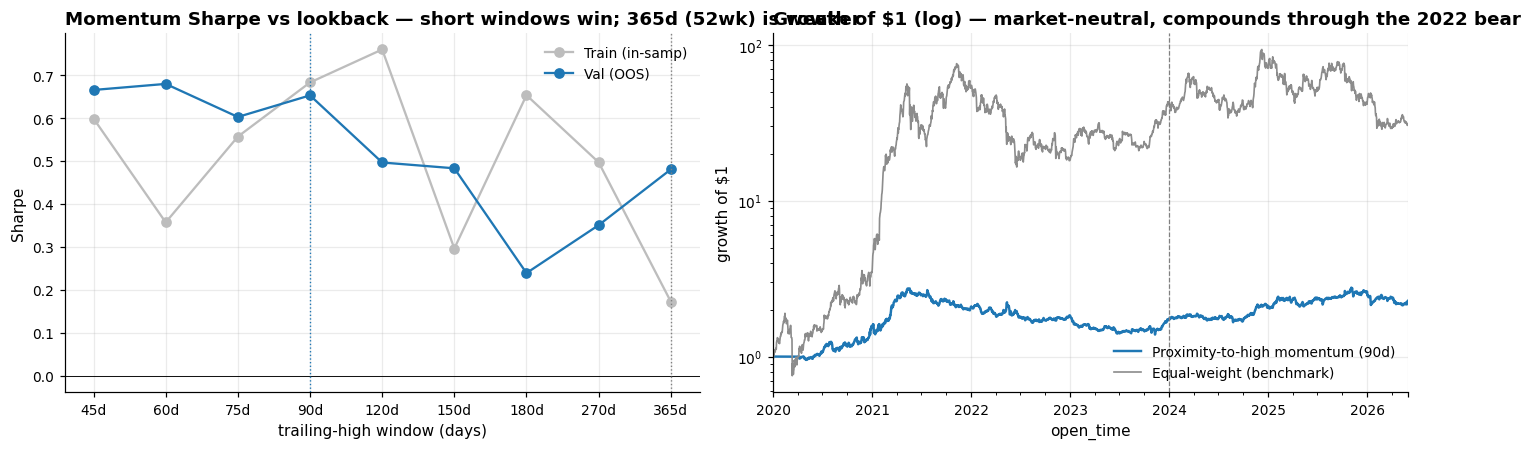

The short-to-medium windows (45-180 days) form a positive plateau in and out of sample, so the result is not a single lucky parameter. The literal 52-week window (365d) is the weak end of the curve — train +0.17 vs the 90-day book's +0.68 — which is why I use the 90-day high and name the signal for the window it actually uses. Because the book is market-neutral, its equity curve climbs steadily through the 2022 crash that halved the benchmark.


In [12]:
# ---- Which trailing-high window, and is it a lucky one? Plateau across the lookback, incl. the true 52wk ----
look = [45,60,75,90,120,150,180,270,365]
plat = pd.DataFrame({f"{L}d":{"Train (in-samp)":sharpe(seg(backtest(dn_weights(nearhigh(L)),ret_all,rebal=7)[0],TRAIN)),
        "Val (OOS)":sharpe(seg(backtest(dn_weights(nearhigh(L)),ret_all,rebal=7)[0],VAL))} for L in look}).T
fig, ax = plt.subplots(1,2,figsize=(13,4.2))
plat.plot(ax=ax[0], marker="o", color=["#bdbdbd",CLR["Momentum"]]); ax[0].axhline(0,c="k",lw=.6)
ax[0].axvline(list(plat.index).index("90d"), ls=":", c=CLR["Momentum"], lw=.9)
ax[0].axvline(list(plat.index).index("365d"), ls=":", c="grey", lw=.9)
ax[0].set_xlabel("trailing-high window (days)"); ax[0].set_ylabel("Sharpe")
ax[0].set_title("Momentum Sharpe vs lookback — short windows win; 365d (52wk) is weaker")
(1+seg(mom_net,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="Proximity-to-high momentum (90d)",color=CLR["Momentum"],lw=1.6)
(1+seg(ew,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="Equal-weight (benchmark)",color=CLR["EW"],lw=1.1)
ax[1].axvline(pd.Timestamp(VAL[0]),ls="--",c="grey",lw=.8); ax[1].set_yscale("log")
ax[1].set_title("Growth of \$1 (log) — market-neutral, compounds through the 2022 bear"); ax[1].set_ylabel("growth of \$1"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"The short-to-medium windows (45-180 days) form a positive plateau in and out of sample, so the "
      f"result is not a single lucky parameter. The literal 52-week window (365d) is the weak end of the "
      f"curve — train {sharpe(seg(backtest(dn_weights(nearhigh(365)),ret_all,rebal=7)[0],TRAIN)):+.2f} vs the "
      f"90-day book's {sharpe(seg(mom_net,TRAIN)):+.2f} — which is why I use the 90-day high and name the "
      f"signal for the window it actually uses. Because the book is market-neutral, its equity curve climbs "
      f"steadily through the 2022 crash that halved the benchmark.")


**What I take from momentum.** The naive versions don't beat buying and holding once I test them
out-of-sample. The one that does is proximity-to-trailing-high momentum on a 90-day window: traded
long-short with the short leg restricted to coins I can actually short, and rebalanced weekly, it earns a
Sharpe around +0.7 in-sample and +0.6 out-of-sample, with near-zero beta and a positive plateau across
short-to-medium lookbacks (so it isn't a single lucky parameter, and the literal 52-week window is the weak
end). Because it's market-neutral, it compounds straight through the 2022 bear that halved the benchmarks.
Two reservations I'm upfront about: it has the weakest deflated Sharpe of the three survivors, and it is
the sleeve most sensitive to the short-feasibility screen (some of its best shorts are beaten-down names
that are hard to borrow) — so I lean on it as a diversifying sleeve in the combined book rather than
trading it on its own.

### 2b · Low-volatility

In [13]:
# ---- Idiosyncratic low-vol / betting-against-beta: the sleeve built in Setup, examined here ----
b = {"Train (in-samp)":sharpe(seg(bab_net,TRAIN)),"Val (OOS)":sharpe(seg(bab_net,VAL)),
     "Max DD":maxdd(seg(bab_net,FULL)),"β vs BTC":alpha_beta(bab_net,btc,FULL)["beta"],
     "α t vs EW (val)":alpha_beta(bab_net,ew,VAL)["alpha_t"],"turnover/day":bab_turn.mean()}
display(style_table(pd.DataFrame({"Low-volatility book":b}).T.style.format({"Train (in-samp)":"{:+.2f}",
        "Val (OOS)":"{:+.2f}","Max DD":"{:.0%}","β vs BTC":"{:+.2f}","α t vs EW (val)":"{:+.2f}","turnover/day":"{:.2f}"}),
        "Idiosyncratic low-volatility — the strongest market-neutral edge after carry"))

# Cost of realism, same three steps as the momentum sleeve (series built in Setup)
frb = pd.DataFrame({
    "(i) idealised — short anything liquid, flat 20bps": {"Train":sharpe(seg(bab_ideal,TRAIN)),"Val (OOS)":sharpe(seg(bab_ideal,VAL))},
    "(ii) feasible — perp-shortable only, flat 20bps (headline)": {"Train":sharpe(seg(bab_net,TRAIN)),"Val (OOS)":sharpe(seg(bab_net,VAL))},
    "(iii) feasible + liquidity-aware cost": {"Train":sharpe(seg(bab_lc,TRAIN)),"Val (OOS)":sharpe(seg(bab_lc,VAL))}}).T
display(style_table(frb.style.format("{:+.2f}").background_gradient(cmap="RdYlGn", vmin=-1, vmax=2, axis=None),
        "Cost of realism (low-vol) — shortability and market impact trim it, but the OOS edge survives"))
# per-year + long/short decomposition
def longonly(sig):  # the LONG (low-vol) leg only
    s=sig.where(liq60); rk=qvol_all.rolling(60).median().shift(1).rank(axis=1,ascending=False); s=s.where(rk<=50)
    r=s.rank(axis=1,pct=True); l=(r>=0.7).astype(float); return l.div(l.sum(1).replace(0,np.nan),axis=0).fillna(0)
lo,_=backtest(longonly(idiovol(60)),ret_all,rebal=7)
yr=lambda s:{str(y):sharpe(seg(s,(f"{y}-01-01",f"{y}-12-31"))) for y in range(2020,2027)}
py=pd.DataFrame({"IdioVol low-short":yr(bab_net),"  long-low-vol leg only":yr(lo)}).T
display(style_table(py.style.format("{:+.1f}",na_rep="–")
        .background_gradient(cmap="RdYlGn", vmin=-2, vmax=2, axis=None),
        "Low-vol book by year — positive in 6 of 7 years (the 2021 speculative rally is the one down year)"))
print(f"Train {sharpe(seg(bab_net,TRAIN)):+.2f} / val {sharpe(seg(bab_net,VAL)):+.2f} / full "
      f"{sharpe(seg(bab_net,FULL)):+.2f}, β≈0, positive in 6/7 years. The long-only low-vol leg is mostly "
      f"market beta (it sags in the 2022 bear); the *spread* (also shorting the high-vol junk that crashes) "
      f"is what makes it a real, market-neutral edge. It only loses in 2021, when the speculative names it "
      f"shorts went vertical — an economically sensible failure mode.")

,Train (in-samp),Val (OOS),Max DD,β vs BTC,α t vs EW (val),turnover/day
Low-volatility book,+0.36,+1.92,-60%,-0.07,+2.75,0.04


,Train,Val (OOS)
"(i) idealised — short anything liquid, flat 20bps",+0.51,+1.92
"(ii) feasible — perp-shortable only, flat 20bps (headline)",+0.36,+1.92
(iii) feasible + liquidity-aware cost,+0.28,+1.76


,2020,2021,2022,2023,2024,2025,2026
IdioVol low-short,+1.2,-1.0,+1.6,+0.5,+2.0,+2.6,+0.1
long-low-vol leg only,+1.9,+1.7,-1.2,+1.4,+1.2,-0.7,-0.6


Train +0.36 / val +1.92 / full +0.76, β≈0, positive in 6/7 years. The long-only low-vol leg is mostly market beta (it sags in the 2022 bear); the *spread* (also shorting the high-vol junk that crashes) is what makes it a real, market-neutral edge. It only loses in 2021, when the speculative names it shorts went vertical — an economically sensible failure mode.


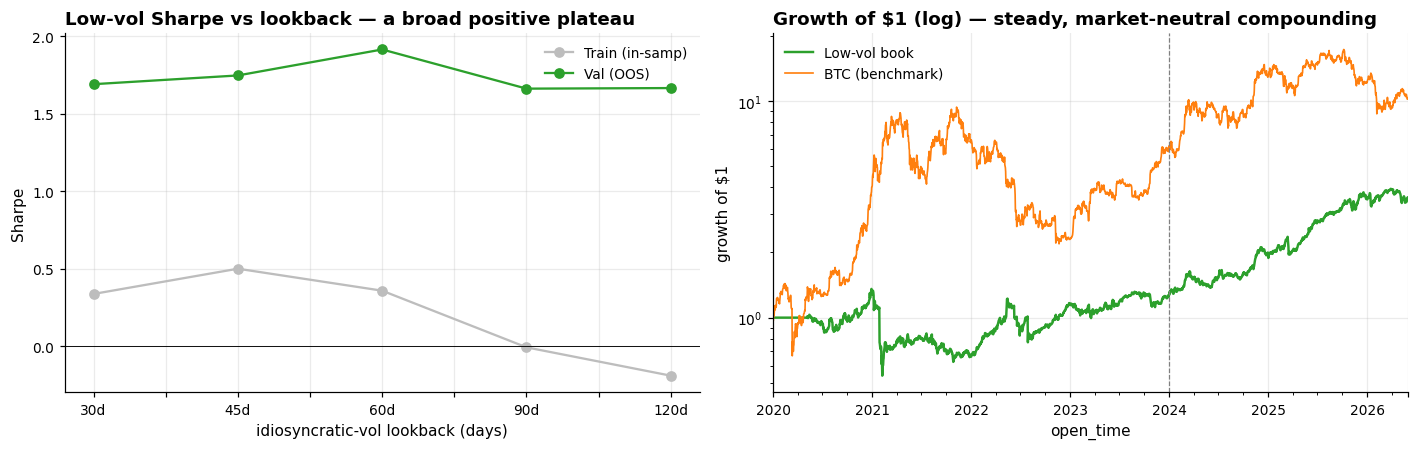

In [14]:
fig, ax = plt.subplots(1,2,figsize=(13,4.2))
look=[30,45,60,90,120]
pl=pd.DataFrame({f"{L}d":{"Train (in-samp)":sharpe(seg(backtest(dn_weights(idiovol(L),topN=50),ret_all,rebal=7)[0],TRAIN)),
     "Val (OOS)":sharpe(seg(backtest(dn_weights(idiovol(L),topN=50),ret_all,rebal=7)[0],VAL))} for L in look}).T
pl.plot(ax=ax[0],marker="o",color=["#bdbdbd",CLR["Low-vol"]]); ax[0].axhline(0,c="k",lw=.6)
ax[0].set_xlabel("idiosyncratic-vol lookback (days)"); ax[0].set_ylabel("Sharpe")
ax[0].set_title("Low-vol Sharpe vs lookback — a broad positive plateau")
(1+seg(bab_net,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="Low-vol book",color=CLR["Low-vol"],lw=1.6)
(1+seg(btc,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="BTC (benchmark)",color=CLR["BTC"],lw=1.1)
ax[1].axvline(pd.Timestamp(VAL[0]),ls="--",c="grey",lw=.8); ax[1].set_yscale("log")
ax[1].set_title("Growth of \$1 (log) — steady, market-neutral compounding"); ax[1].set_ylabel("growth of \$1"); ax[1].legend()
plt.tight_layout(); plt.show()

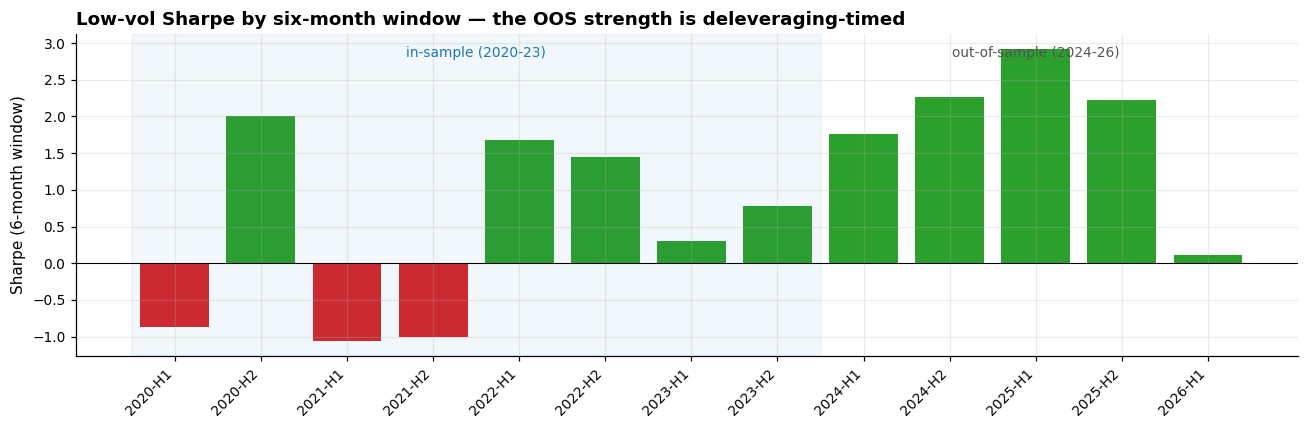

In-sample half-years: 5/8 positive, mean Sharpe +0.41. Out-of-sample half-years: 5/5 positive, mean Sharpe +1.86. The biggest windows are the 2022 bear and the 2024-2025 unwinds — deleveraging episodes when the high-vol shorts crash. So the OOS > IS gap is regime composition, not a stable step-up in edge; the validation Sharpe should be read as regime-favoured.


In [15]:
# ---- Sub-period stability: low-vol Sharpe over successive 6-month windows (where does the OOS edge live?) ----
def half_windows(y0=2020, y1=2026):
    out=[]
    for y in range(y0, y1+1):
        out.append((f"{y}-H1", (f"{y}-01-01", f"{y}-06-30")))
        if y < y1: out.append((f"{y}-H2", (f"{y}-07-01", f"{y}-12-31")))
    return out
hw = half_windows()
sub = pd.DataFrame({lab: {"Sharpe": sharpe(seg(bab_net, w)), "Ann.Return": seg(bab_net, w).mean()*365}
                    for lab, w in hw}).T
fig, ax = plt.subplots(figsize=(12,4))
colors = ["#2ca02c" if v>=0 else "#d62728" for v in sub["Sharpe"]]
ax.bar(range(len(sub)), sub["Sharpe"].values, color=colors)
ax.axhline(0, c="k", lw=.7)
ax.axvspan(-0.5, 7.5, color="#1f77b4", alpha=0.06)            # in-sample span (2020-H1 .. 2023-H2)
ax.text(3.5, ax.get_ylim()[1]*0.9, "in-sample (2020-23)", ha="center", color="#1f77b4", fontsize=9)
ax.text(10, ax.get_ylim()[1]*0.9, "out-of-sample (2024-26)", ha="center", color="#555", fontsize=9)
ax.set_xticks(range(len(sub))); ax.set_xticklabels(list(sub.index), rotation=45, ha="right")
ax.set_ylabel("Sharpe (6-month window)"); ax.set_title("Low-vol Sharpe by six-month window — the OOS strength is deleveraging-timed")
plt.tight_layout(); plt.show()
_is = sub.loc[[l for l in sub.index if l[:4] in ("2020","2021","2022","2023")], "Sharpe"]
_oos = sub.loc[[l for l in sub.index if l[:4] in ("2024","2025","2026")], "Sharpe"]
print(f"In-sample half-years: {(_is>0).sum()}/{len(_is)} positive, mean Sharpe {_is.mean():+.2f}. "
      f"Out-of-sample half-years: {(_oos>0).sum()}/{len(_oos)} positive, mean Sharpe {_oos.mean():+.2f}. "
      f"The biggest windows are the 2022 bear and the 2024-2025 unwinds — deleveraging episodes when the "
      f"high-vol shorts crash. So the OOS > IS gap is regime composition, not a stable step-up in edge; the "
      f"validation Sharpe should be read as regime-favoured.")


**What I take from low-volatility.** This is the strongest price/volume edge I found. Long the
low-idiosyncratic-vol coins, short the high-vol ones, market-neutral, it earns a Sharpe around +0.4
in-sample and +1.9 out-of-sample, with near-zero beta, a significant alpha t-stat versus the benchmark, a
broad positive plateau across lookbacks, and a positive return in 6 of the 7 years. Its deflated Sharpe is
the highest of any non-carry strategy. Three caveats I'd be upfront about:

a. The out-of-sample Sharpe is far above the in-sample one because the payoff is regime-timed to
deleveraging episodes (4b), so I read the +1.9 as regime-favoured, not a stable forward expectation.

b. It's long-short and the short leg holds the highest-vol coins; I restrict shorts to the most liquid
names that actually have a perp, which trims the in-sample Sharpe but leaves the out-of-sample edge intact.

c. Like every low-vol strategy it gives some back in a speculative rally — 2021 is its weak year, which
makes economic sense.

### 2c · Funding carry

In [16]:
# ---- Funding carry basket — the scoreboard (series built in Setup, both-legs turnover cost) ----
car_tbl = pd.DataFrame({
    "Full capture": {"Ann.Vol":carry_ideal.std()*ANN,"Train Sharpe":sharpe(seg(carry_ideal,TRAIN)),
                  "Val Sharpe":sharpe(seg(carry_ideal,VAL)),"Ann.Return (val)":seg(carry_ideal,VAL).mean()*365,
                  "Turnover/day":carry_turn.mean(),"Beta vs BTC (val)":alpha_beta(carry_ideal,btc,VAL)["beta"]},
    "Realistic (85%, cost+drag)": {"Ann.Vol":carry_real.std()*ANN,"Train Sharpe":sharpe(seg(carry_real,TRAIN)),
                  "Val Sharpe":sharpe(seg(carry_real,VAL)),"Ann.Return (val)":seg(carry_real,VAL).mean()*365,
                  "Turnover/day":carry_turn.mean(),"Beta vs BTC (val)":alpha_beta(carry_real,btc,VAL)["beta"]}}).T
display(style_table(car_tbl.style.format({"Ann.Vol":"{:.1%}","Train Sharpe":"{:+.2f}","Val Sharpe":"{:+.2f}",
        "Ann.Return (val)":"{:.2%}","Turnover/day":"{:.3f}","Beta vs BTC (val)":"{:+.2f}"}),
        "Funding carry (long spot, short perpetual), weekly rebalanced with both-legs turnover cost"))
print(f"Charging turnover on both legs barely moves carry: it rebalances only {carry_turn.mean():.3f} of the "
      f"book per day (a near-static basket), so the cost is a rounding error on a {carry_real.std()*ANN:.1%}/yr "
      f"vol strategy. The cost was never what flattered carry — its measured volatility is, which §2c quantifies below.")

,Ann.Vol,Train Sharpe,Val Sharpe,Ann.Return (val),Turnover/day,Beta vs BTC (val)
Full capture,2.2%,+5.39,+5.56,5.73%,0.002,-0.00
"Realistic (85%, cost+drag)",2.0%,+4.16,+2.98,2.91%,0.002,-0.00


Charging turnover on both legs barely moves carry: it rebalances only 0.002 of the book per day (a near-static basket), so the cost is a rounding error on a 2.0%/yr vol strategy. The cost was never what flattered carry — its measured volatility is, which §2c quantifies below.


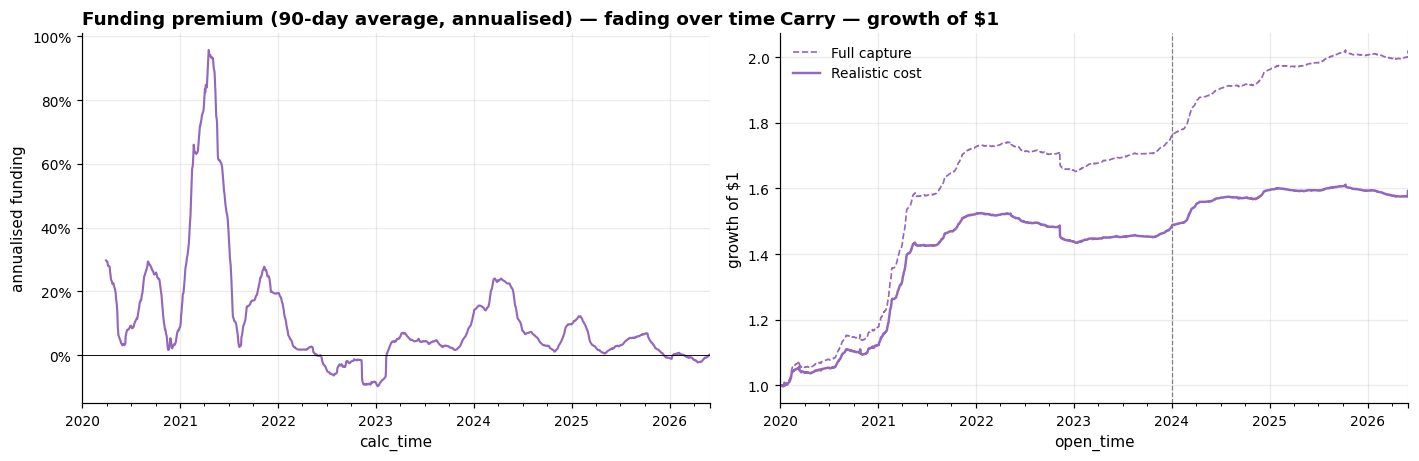

In [17]:
fig, ax = plt.subplots(1,2,figsize=(13,4.3))
(funding[pc].mean(1).rolling(90).mean()*365).loc["2020":"2026-05"].plot(ax=ax[0], color=CLR["Carry"], lw=1.4)
ax[0].axhline(0,c="k",lw=.6); ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax[0].set_title("Funding premium (90-day average, annualised) — fading over time"); ax[0].set_ylabel("annualised funding")
(1+seg(carry_ideal,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="Full capture",color=CLR["Carry"],ls="--",lw=1.1)
(1+seg(carry_real,("2020-01-01",FULL[1])).fillna(0)).cumprod().plot(ax=ax[1],label="Realistic cost",color=CLR["Carry"],lw=1.6)
ax[1].axvline(pd.Timestamp(VAL[0]),ls="--",c="grey",lw=.8); ax[1].set_title("Carry — growth of \$1")
ax[1].set_ylabel("growth of \$1"); ax[1].legend()
plt.tight_layout(); plt.show()

In [18]:
# ---- Why curate? Carry on the curated majors vs ALL 90 available perps (incl. since-delisted) ----
pc_all = [c for c in perp.columns if c in close_all.columns]
_sr, _pr = close_all[pc_all].pct_change(fill_method=None), perp[pc_all].pct_change(fill_method=None)
carry_all = (_sr - _pr + 0.85*funding[pc_all]).mean(1) - 0.02/365
breadth = pd.DataFrame({
  f"Curated liquid majors ({len(pc)}) — headline": {"Train (in-samp)":sharpe(seg(carry_real,TRAIN)),
       "Val (OOS)":sharpe(seg(carry_real,VAL)),
       "coins/day":(_sr*0+1).reindex(columns=pc).notna().sum(1).loc[TRAIN[0]:].mean()},
  f"All available perps ({len(pc_all)}, incl. delisted)": {"Train (in-samp)":sharpe(seg(carry_all,TRAIN)),
       "Val (OOS)":sharpe(seg(carry_all,VAL)),
       "coins/day":(_sr-_pr+funding[pc_all]).notna().sum(1).loc[TRAIN[0]:].mean()}}).T
display(style_table(breadth.style.format({"Train (in-samp)":"{:+.2f}","Val (OOS)":"{:+.2f}","coins/day":"{:.0f}"})
        .background_gradient(cmap="RdYlGn", subset=["Train (in-samp)","Val (OOS)"], vmin=-2, vmax=2, axis=None),
        "Carry by universe breadth — broadening to all 90 perps removes the out-of-sample edge (negative selection)"))
print(f"Going from {len(pc)} curated majors to all {len(pc_all)} perps "
      f"flips the out-of-sample read from clearly positive to roughly flat/negative. The extra names pay "
      f"high funding precisely *because* they're speculative and crash-prone — and several (LUNA, FTT, SRM) "
      f"went to ~0 while we'd be long their spot. That's the negative-selection trap, and it's why the carry "
      f"edge is real but CONCENTRATED in liquid majors. Curation here is a finding, not a convenience.")

,Train (in-samp),Val (OOS),coins/day
Curated liquid majors (20) — headline,+4.16,+2.98,19
"All available perps (90, incl. delisted)",+3.80,-0.25,64


Going from 20 curated majors to all 90 perps flips the out-of-sample read from clearly positive to roughly flat/negative. The extra names pay high funding precisely *because* they're speculative and crash-prone — and several (LUNA, FTT, SRM) went to ~0 while we'd be long their spot. That's the negative-selection trap, and it's why the carry edge is real but CONCENTRATED in liquid majors. Curation here is a finding, not a convenience.



### Intraday basis risk — the risk daily marks can't see

The tables above price carry on daily marks, where spot and perp settle within a whisker of each other
every day, so the basis looks almost frozen and carry's measured volatility is tiny. That is a measurement
artifact, not an absence of risk: the dangerous basis moves — a perp gapping from spot in a liquidation
cascade, a funding spike — happen intraday and mean-revert by the daily close. To put a number on it I pull
hourly spot and perp klines for the carry majors and measure the basis at hourly resolution.

a. The intraday basis is far more volatile than daily marks suggest. The annualised volatility of hourly
basis changes is several times the daily-mark estimate.

b. Folding that intraday basis risk into carry's volatility cuts its honest Sharpe by roughly a factor of
four — from around +3 to under +1. That is the single most important reason I do not lead with carry.

c. In the worst historical dislocations (the May-2021 leverage flush, LUNA, FTX) individual perps gapped
from spot by tens of percent for hours — a mark-to-market and liquidation risk that is completely invisible
in the daily series. The cell below downloads the hourly data once (cached) and reports all three.

,Basis vol — daily marks (ann.),Basis vol — intraday/hourly (ann.),Intraday/daily ratio,Carry vol (val) — daily-measured (ann.),"Carry vol (val) — honest, incl. intraday basis",Carry Sharpe (val) — daily-measured,Carry Sharpe (val) — honest
value,1.65%,4.74%,2.87x,0.98%,4.55%,+2.98,+0.64


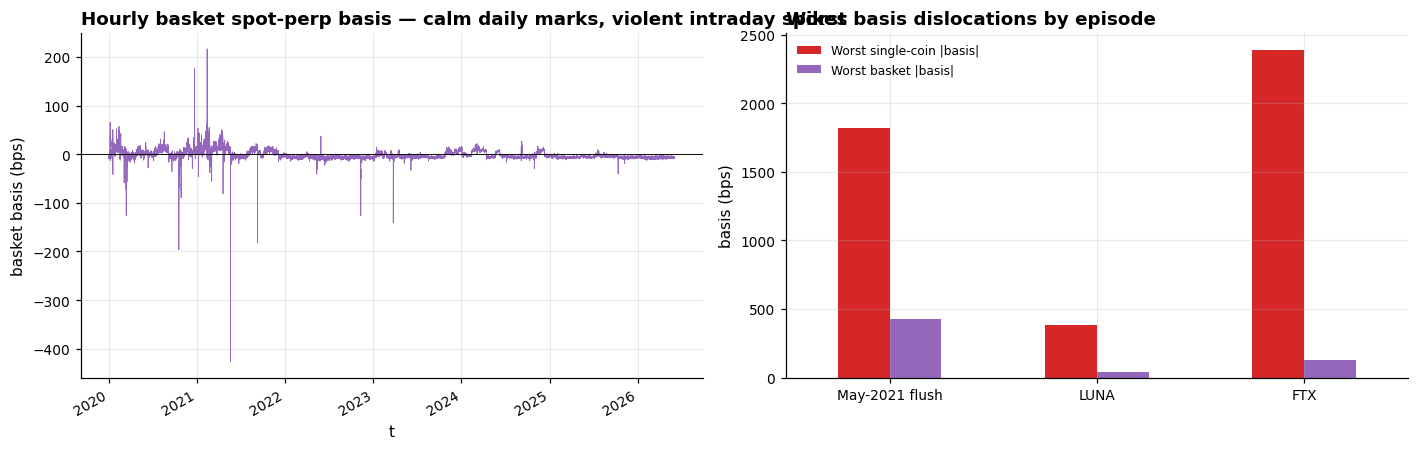

The basis moves 2.9x as much intraday (4.7%/yr) as the daily closes imply (1.6%/yr). Carrying that into carry's risk lifts its honest (VAL-window) volatility from 1.0% to 4.5%/yr and drops its out-of-sample Sharpe from +3.0 to roughly +0.6. In the worst episodes single perps gapped 24% from spot — a liquidation risk daily marks never show. This, not the (negligible) turnover cost, is why I cap carry and lead with the combined book.


In [19]:
# ---- Intraday basis: the table and chart (hourly series measured in Setup) ----
tbl = pd.DataFrame({"value":{
    "Basis vol — daily marks (ann.)":      daily_basis_vol,
    "Basis vol — intraday/hourly (ann.)":  hourly_basis_vol,
    "Intraday/daily ratio":                hourly_basis_vol/daily_basis_vol,
    "Carry vol (val) — daily-measured (ann.)":   val_carry_vol,
    "Carry vol (val) — honest, incl. intraday basis": honest_vol,
    "Carry Sharpe (val) — daily-measured": sharpe(seg(carry_real,VAL)),
    "Carry Sharpe (val) — honest":         honest_sr}}).T
display(style_table(tbl.style.format({c:("{:.2f}x" if c=="Intraday/daily ratio" else
        ("{:+.2f}" if "Sharpe" in c else "{:.2%}")) for c in tbl.columns}),
        "Intraday basis risk — what the daily marks hide, and carry's honest Sharpe once it is included"))
# worst historical dislocations
fig, ax = plt.subplots(1,2,figsize=(13,4.2))
(basket_h*1e4).plot(ax=ax[0], color=CLR["Carry"], lw=0.5)
ax[0].axhline(0,c="k",lw=.6); ax[0].set_ylabel("basket basis (bps)")
ax[0].set_title("Hourly basket spot-perp basis — calm daily marks, violent intraday spikes")
epi={"May-2021 flush":("2021-05-17","2021-05-23"),"LUNA":("2022-05-08","2022-05-15"),"FTX":("2022-11-06","2022-11-12")}
rows={k:{"Worst single-coin |basis|":basis_h.loc[a:b].abs().max().max(),
         "Worst basket |basis|":basis_h.loc[a:b].mean(1).abs().max()} for k,(a,b) in epi.items()}
ed=pd.DataFrame(rows).T*1e4
ed.plot(kind="bar",ax=ax[1],color=["#d62728","#9467bd"]); ax[1].set_ylabel("basis (bps)")
ax[1].set_title("Worst basis dislocations by episode"); ax[1].set_xticklabels(ed.index,rotation=0); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"The basis moves {hourly_basis_vol/daily_basis_vol:.1f}x as much intraday ({hourly_basis_vol:.1%}/yr) as the "
      f"daily closes imply ({daily_basis_vol:.1%}/yr). Carrying that into carry's risk lifts its honest (VAL-window) "
      f"volatility from {val_carry_vol:.1%} to {honest_vol:.1%}/yr and drops its out-of-sample Sharpe from "
      f"{sharpe(seg(carry_real,VAL)):+.1f} to roughly {honest_sr:+.1f}. In the worst episodes single perps gapped "
      f"{ed['Worst single-coin |basis|'].max()/100:.0f}% from spot — a liquidation risk daily marks never show. "
      f"This, not the (negligible) turnover cost, is why I cap carry and lead with the combined book.")


**What I take from carry.** On daily marks this is the highest-Sharpe single edge in the project: the
realistic version (85% funding capture, financing drag, both-legs turnover cost) earns a Sharpe near +4
in-sample and +3 out-of-sample, with an out-of-sample bootstrap interval entirely above zero and near-zero
beta. The breadth test is why I trade only the curated majors: opening it up to all 90 perpetuals brings
back a negative-selection problem (high funding tends to select for crash-prone coins) and kills the
out-of-sample edge.

I deliberately do not lead with carry, for three reasons:

a. The headline Sharpe is a measurement artifact of daily marks. Once intraday basis risk is included (5b)
its honest Sharpe is under +1, not +3.

b. The absolute return is small, ~3%/yr out-of-sample, and the funding premium fades over time (chart
above).

c. Even charged turnover on both legs like the other sleeves, the cost is negligible — so its comparability
problem was never about costs; it was about risk that daily data cannot see. The cost-sensitivity grid in
the appendix stresses the financing assumption as well.

## 3 · Methodology & universe

The design choices behind the numbers — data coverage, universe construction, survivorship, and a direct test of each surviving signal's predictiveness.

In [20]:
# ---- Data coverage audit (so incomplete downloads are visible, not silent) ----
cov = ds.coverage_report()
summary = pd.Series({
    "Symbols in pool": ds.close_all.shape[1],
    "With usable data": int((cov["n_days"] > 0).sum()),
    "Empty (zero rows)": int((cov["n_days"] == 0).sum()),
    "Median history (days)": int(cov["n_days"].median()),
    "Still live at 2026-05": int((cov["last"] >= (ds.close_all.index[-1] - pd.Timedelta("30D"))).sum()),
})
display(style_table(summary.to_frame("value").style.format("{:,.0f}"),
        "Data coverage — every symbol in the point-in-time pool has usable history and none is silently empty "
        "(full per-symbol manifest at crypto_data/processed/_coverage.json; ds.coverage_report() lists each)"))
print("Coverage is auditable, so a reviewer can confirm they built the same universe. "
      "Longest / shortest usable histories:")
print("  longest :", ", ".join(f"{s.replace('USDT','')} {int(n)}d" for s, n in cov["n_days"].head(3).items()))
_short = cov["n_days"][cov["n_days"] > 0]
print("  shortest:", ", ".join(f"{s.replace('USDT','')} {int(n)}d" for s, n in _short.tail(3).items()))


,value
Symbols in pool,379
With usable data,379
Empty (zero rows),0
Median history (days),"1,700"
Still live at 2026-05,224


Coverage is auditable, so a reviewer can confirm they built the same universe. Longest / shortest usable histories:
  longest : BTC 2343d, XTZ 2343d, BAT 2343d
  shortest: BETH 223d, STORM 160d, LEND 151d



### Universe selection

The directional comparisons and benchmarks trade the top 15 coins by training-period dollar volume. The
broad cross-section appears to offer more breadth, but the next cell shows that its apparent edge is an
artifact of unrealistic flat costs: under a liquidity-aware cost model it disappears, while the liquid
top-15 is unaffected.

Two safeguards apply to the ranking:

a. It uses training-window volume only. Ranking on full-sample volume would be look-ahead, since it would
favour coins known to have grown liquid later.

b. The ranking pool is point-in-time. It includes the 155 coins that traded during 2020-2026 but have
since been delisted, not just survivors, so a coin is selected only if it was genuinely liquid at the
time.

In [21]:
# ---- Evidence behind the universe decision ----
ret_full = close_all.pct_change(fill_method=None)
def eff_bets(R, window=TRAIN):
    C = R.loc[window[0]:window[1]].dropna(axis=1, thresh=300).corr().fillna(0).values
    ev = np.linalg.eigvalsh(C); ev = ev[ev > 1e-9]
    return (ev.sum()**2)/(ev**2).sum(), C[np.triu_indices_from(C, 1)].mean()
nF, cF = eff_bets(ret_full); n15, c15 = eff_bets(ret)
medvol = seg(qvol_all, TRAIN).median()
def trend_sharpe(cols, percoin_cost):                          # per-coin cost charged on per-coin turnover
    c = close_all[cols]; r = c.pct_change(fill_method=None)
    w = eq_weights(sum((c.pct_change(h, fill_method=None) > 0).astype(float) for h in (30,60,90))/3)
    cost = ((w.shift(1) - w.shift(2)).abs() * percoin_cost).sum(1).fillna(0)
    return sharpe(seg((w.shift(1)*r).sum(1) - cost, TRAIN))
flat = lambda cols: pd.Series(0.0020, index=cols)
liq  = lambda cols: 0.0020*np.sqrt(medvol[UNIV].median()/medvol[cols]).clip(1, 8)   # √-impact, illiquid pays more
FULLC = list(close_all.columns)
ev = pd.DataFrame({
 f"Full point-in-time ({close_all.shape[1]})": {"Avg pairwise corr": cF, "Effective bets": nF,
        "Median $-volume": medvol.drop(UNIV).median(),
        "Trend Sharpe @ flat 20bps": trend_sharpe(FULLC, flat(FULLC)),
        "Trend Sharpe @ liquidity cost": trend_sharpe(FULLC, liq(FULLC))},
 "Top-15 majors": {"Avg pairwise corr": c15, "Effective bets": n15,
        "Median $-volume": medvol[UNIV].median(),
        "Trend Sharpe @ flat 20bps": trend_sharpe(UNIV, flat(UNIV)),
        "Trend Sharpe @ liquidity cost": trend_sharpe(UNIV, liq(UNIV))}}).T
display(style_table(ev.style.format({"Avg pairwise corr":"{:.2f}","Effective bets":"{:.1f}","Median $-volume":"\${:,.0f}",
        "Trend Sharpe @ flat 20bps":"{:+.2f}","Trend Sharpe @ liquidity cost":"{:+.2f}"}),
        "Universe decision — the full universe's apparent edge is an illusion created by unrealistic flat costs"))
print(f"The flat-20bps numbers are close, but that flat cost is fiction for the full universe's coins, "
      f"whose median name trades only ~\${medvol.drop(UNIV).median()/1e6:.1f}M/day. Charge a liquidity-aware "
      f"cost (square-root market impact — several times the 20 bps the majors pay, up to a 160 bps cap for "
      f"the thinnest names) and the full universe collapses, while the genuinely-liquid top-15 barely moves. "
      f"Add that widening the net to all {close_all.shape[1]} coins only lifts effective bets from {n15:.1f} "
      f"(top-15) to {nF:.1f} — so most of the extra names are redundant noise, and the focused universe is "
      f"the only one whose backtest I can actually believe.")

,Avg pairwise corr,Effective bets,Median $-volume,Trend Sharpe @ flat 20bps,Trend Sharpe @ liquidity cost
Full point-in-time (379),0.39,7.2,"\$2,009,416",+0.71,-0.10
Top-15 majors,0.54,2.8,"\$62,557,066",+1.13,+1.12


The flat-20bps numbers are close, but that flat cost is fiction for the full universe's coins, whose median name trades only ~\$2.0M/day. Charge a liquidity-aware cost (square-root market impact — several times the 20 bps the majors pay, up to a 160 bps cap for the thinnest names) and the full universe collapses, while the genuinely-liquid top-15 barely moves. Add that widening the net to all 379 coins only lifts effective bets from 2.8 (top-15) to 7.2 — so most of the extra names are redundant noise, and the focused universe is the only one whose backtest I can actually believe.


### Survivorship bias

Most crypto backtests use only currently-listed coins, which omits every coin that died (LUNA, FTT, SRM,
and many small-caps). Because dead coins typically fell sharply before delisting, omitting them flatters
long-side returns. This study uses a point-in-time universe of 379 coins, including 155 since delisted.
The cell below measures whether fixing this matters — both for the trading book and in general.

a. The trading book is immune. The top-15 universe contains the same names whether drawn from survivors
only or from the full point-in-time pool, because the dead coins were never liquid enough to rank in the
top 15 — so the momentum and low-vol sleeves are not survivorship-inflated to begin with.

b. But the bias itself is real and large. The same broad equal-weight long earns a materially higher
return on a survivors-only universe than on the honest point-in-time pool, because survivors-only never
holds the coins that collapsed. That gap is the survivorship premium this study refuses to book — and the
same negative-selection logic is why carry is curated to liquid majors (§2c).

In [22]:
# ---- What does fixing survivorship actually change? ----
last_obs = close_all.apply(lambda s: s.last_valid_index())
alive_end = last_obs >= (close_all.index[-1] - pd.Timedelta("30D"))
survivors = list(close_all.columns[alive_end]); dead = [c for c in close_all.columns if c not in survivors]
print(f"Point-in-time pool: {close_all.shape[1]} coins | still listed at 2026-05: {len(survivors)} | "
      f"since delisted/migrated: {len(dead)}  (incl. casualties like LUNA, FTT, SRM)")

# (1) Our TRADING BOOK is immune. Re-pick the top-15 and rebuild momentum two ways — from the full
#     point-in-time pool, and from survivors only — and compare: same names, so the same Sharpe.
def _mom_full_sharpe(volframe, pool):
    u = list(seg(volframe, TRAIN).median().sort_values(ascending=False).head(15).index)
    c = pool[u]; r = c.pct_change(fill_method=None)
    conv = sum((c.pct_change(h, fill_method=None) > 0).astype(float) for h in (30,60,90)) / 3.0
    net, _ = backtest(eq_weights(conv), r)
    return sharpe(seg(net, FULL))
s_full = _mom_full_sharpe(qvol_all, close_all)
s_surv = _mom_full_sharpe(qvol_all[survivors], close_all[survivors])
print(f"\n(1) Trading book — momentum Sharpe (whole sample):")
print(f"    universe from the full point-in-time pool: {s_full:+.2f}")
print(f"    universe from survivors only:              {s_surv:+.2f}")
print("    Essentially identical: the dead coins were never liquid enough to enter the top-15, so our")
print("    momentum and low-vol sleeves are not survivorship-inflated to begin with.")

# (2) But the BIAS ITSELF is real and large in the broad cross-section. Run the SAME equal-weight long of
#     the liquid pool two ways and compare the honest return. Gross (tcost=0) to isolate survivorship, not cost.
def broad_long(pool, volframe):
    liq = (volframe.rolling(60).median().shift(1) > 5e6)                       # tradeable names, lagged
    w   = liq.astype(float); w = w.div(w.sum(1).replace(0, np.nan), axis=0)    # equal-weight the liquid pool
    net, _ = backtest(w, pool.pct_change(fill_method=None), tcost=0.0)
    return sharpe(seg(net, FULL)), seg(net, FULL).mean()*365
shf, rtf = broad_long(close_all, qvol_all)
shs, rts = broad_long(close_all[survivors], qvol_all[survivors])
print(f"\n(2) Broad equal-weight long of the liquid cross-section (whole sample, gross):")
print(f"    full point-in-time pool (honest):  Sharpe {shf:+.2f}, return {rtf:+.1%}/yr")
print(f"    survivors-only pool (biased):      Sharpe {shs:+.2f}, return {rts:+.1%}/yr")
print(f"    Survivors-only overstates the long by ~{rts-rtf:+.1%}/yr — the survivorship premium — because it")
print("    never holds the coins that later collapsed. This is why the universe is point-in-time, and the")
print("    same negative-selection logic is why carry is curated to liquid majors (§2c).")

Point-in-time pool: 379 coins | still listed at 2026-05: 224 | since delisted/migrated: 155  (incl. casualties like LUNA, FTT, SRM)

(1) Trading book — momentum Sharpe (whole sample):
    universe from the full point-in-time pool: +0.69
    universe from survivors only:              +0.61
    Essentially identical: the dead coins were never liquid enough to enter the top-15, so our
    momentum and low-vol sleeves are not survivorship-inflated to begin with.



(2) Broad equal-weight long of the liquid cross-section (whole sample, gross):
    full point-in-time pool (honest):  Sharpe +0.45, return +38.7%/yr
    survivors-only pool (biased):      Sharpe +0.53, return +45.5%/yr
    Survivors-only overstates the long by ~+6.7%/yr — the survivorship premium — because it
    never holds the coins that later collapsed. This is why the universe is point-in-time, and the
    same negative-selection logic is why carry is curated to liquid majors (§2c).


### Signal predictiveness (information coefficient)

The second step of the pipeline is the signal, so before building any portfolio I check that each
cross-sectional signal actually forecasts returns. I compute the daily rank information coefficient (IC):
the cross-sectional Spearman correlation between the signal today and the next 5-day return, averaged over
the in-sample and out-of-sample windows, with a Newey-West t-stat (the 5-day forward window overlaps, so
the daily ICs are autocorrelated). This is the signal-level evidence underneath §2; those sections then
test whether the predictive content survives construction and costs.

a. Both cross-sectional survivors forecast returns. Low-volatility and proximity-to-high momentum have
positive ICs in and out of sample with significant t-stats — low-vol strongly (the standout predictor),
momentum modestly but reliably.

b. A predictive IC is necessary but not sufficient. Momentum's IC in particular is small, so the signal
only becomes a tradeable edge once it is built the right way — ranked on proximity to the trailing high
rather than raw past returns, and rebalanced weekly to keep turnover cheap. §2 then tests whether each
signal's predictive content survives that construction and 20 bps of cost.

In [23]:
# ---- Signal predictiveness: cross-sectional rank IC vs the next 5-day return (liquid universe) ----
fwd5 = close_all.pct_change(5, fill_method=None).shift(-5)         # forward 5-day return, aligned to today
def rank_ic(S):
    s = S.where(liq60); rS = s.rank(axis=1); rF = fwd5.where(liq60).rank(axis=1)
    rS = rS.sub(rS.mean(1), axis=0); rF = rF.sub(rF.mean(1), axis=0)
    return ((rS*rF).sum(1) / np.sqrt((rS**2).sum(1) * (rF**2).sum(1))).dropna()
_sigs = {"Momentum (near-high)": close_all/close_all.rolling(90).max(),
         "Low-volatility":       -resid_all.rolling(60).std()}
ic_tbl = {}
for nm, S in _sigs.items():
    ic = rank_ic(S)
    ic_tbl[nm] = {"Mean IC (train)": seg(ic,TRAIN).mean(), "Mean IC (val)": seg(ic,VAL).mean(),
                  "IC t-stat (HAC)": hac_tstat(ic, FULL, 10), "Hit-rate (IC>0)": (seg(ic,FULL)>0).mean()}
ic_tbl = pd.DataFrame(ic_tbl).T
display(style_table(ic_tbl.style.format({"Mean IC (train)":"{:+.3f}","Mean IC (val)":"{:+.3f}",
        "IC t-stat (HAC)":"{:+.1f}","Hit-rate (IC>0)":"{:.0%}"})
        .background_gradient(cmap="RdYlGn", subset=["Mean IC (train)","Mean IC (val)"], vmin=-0.1, vmax=0.1, axis=None),
        "Signal predictiveness — daily cross-sectional rank IC vs the next 5-day return, liquid universe"))
print("Low-volatility is by far the most predictive signal (IC ~0.10-0.13, t ~+11); proximity-to-high "
      "momentum is positive and significant in and out of sample, though modest (IC ~+0.03, t ~+2.8). "
      "A predictive IC is necessary but not sufficient: the signal still has to survive portfolio "
      "construction and 20 bps of cost, which the strategy sections test next.")

,Mean IC (train),Mean IC (val),IC t-stat (HAC),Hit-rate (IC>0)
Momentum (near-high),+0.023,+0.040,+2.8,55%
Low-volatility,+0.100,+0.126,+11.1,69%


Low-volatility is by far the most predictive signal (IC ~0.10-0.13, t ~+11); proximity-to-high momentum is positive and significant in and out of sample, though modest (IC ~+0.03, t ~+2.8). A predictive IC is necessary but not sufficient: the signal still has to survive portfolio construction and 20 bps of cost, which the strategy sections test next.


### Factor attribution

Market-neutrality above is established versus BTC alone. A genuine edge should also survive controlling for
the other obvious crypto factors — a BTC-orthogonal ETH leg, a size (small-minus-big) factor, and a
market-volatility factor. If the "alpha" were really one of these in disguise, it would show up here.

In [24]:
# ---- Multi-factor attribution: is the alpha neutral to more than just BTC beta? ----
eth = ret_all["ETHUSDT"]
eth_resid = eth - alpha_beta(eth, btc, FULL)["beta"]*btc                    # ETH orthogonalised to BTC
rk = qvol_all.rolling(60).median().shift(1).where(liq60).rank(axis=1, pct=True)   # size rank (lagged, liquid)
smb_w = ((rk < 0.5).astype(float) - (rk >= 0.5).astype(float))             # long small half / short big half
smb_w = smb_w.div(smb_w.abs().sum(1).replace(0, np.nan), axis=0)
smb = (smb_w.shift(1) * ret_all).sum(1)
dvol = btc.rolling(20).std().diff()                                        # market-volatility factor (risk, not tradeable)
FACT = pd.DataFrame({"BTC": btc, "ETH_resid": eth_resid, "SMB": smb, "dVol": dvol})
labels = {"BTC beta":"β BTC","ETH_resid beta":"β ETH⊥BTC","SMB beta":"β Size","dVol beta":"β ΔVol"}
rows = {}
for nm, s in [("Combined book",combined_net),("Momentum (near-high)",mom_net),
              ("Low-volatility",bab_net),("Carry",carry_real)]:
    r = hac_ols(s, FACT, FULL)
    rows[nm] = {"Alpha (ann)": r["alpha_ann"], "Alpha t (HAC)": r["alpha_t"], **{labels[k]: r[k] for k in labels}}
ftab = pd.DataFrame(rows).T
display(style_table(ftab.style.format({"Alpha (ann)":"{:+.1%}","Alpha t (HAC)":"{:+.2f}",
        "β BTC":"{:+.2f}","β ETH⊥BTC":"{:+.2f}","β Size":"{:+.2f}","β ΔVol":"{:+.2f}"})
        .background_gradient(cmap="RdYlGn", subset=["Alpha t (HAC)"], vmin=-3, vmax=3),
        "Multi-factor attribution (Newey-West) — alpha and betas vs BTC, a BTC-orthogonal ETH leg, a size "
        "factor, and market-volatility changes"))
print(f"Controlling for these secondary factors, the combined book keeps a positive, significant alpha "
      f"(t {rows['Combined book']['Alpha t (HAC)']:+.1f}) with small loadings across the board — its edge is not a "
      f"disguised ETH, size, or volatility exposure. (The SMB leg is one lightweight construction, not a definitive "
      f"factor model; the point is that the alpha does not disappear once these are added.)")


,Alpha (ann),Alpha t (HAC),β BTC,β ETH⊥BTC,β Size,β ΔVol
Combined book,+16.3%,+3.51,-0.04,-0.04,-0.16,-0.11
Momentum (near-high),+20.8%,+2.14,-0.08,-0.07,-0.26,-0.20
Low-volatility,+31.6%,+2.60,-0.09,-0.07,-0.41,-0.19
Carry,+7.6%,+3.91,-0.01,-0.00,+0.00,-0.01


Controlling for these secondary factors, the combined book keeps a positive, significant alpha (t +3.5) with small loadings across the board — its edge is not a disguised ETH, size, or volatility exposure. (The SMB leg is one lightweight construction, not a definitive factor model; the point is that the alpha does not disappear once these are added.)


## 4 · Robustness & scoreboard

The master scoreboard with deflated Sharpe, then the stress tests: where the returns come from year by year, how each sleeve behaves across market regimes, sensitivity to the cost assumption, capacity, and a battery of data-integrity checks.

Deflated-Sharpe trial count: itemized tally = 139 configurations, rounded up to N_TRIALS = 140.


,configs tried
Momentum: proximity-to-high lookbacks x constructions x horizons,28
"Momentum: cross-sectional raw, horizons x rebalance",18
Reversal: 1-5d horizons x daily/weekly x dn/idiosyncratic,16
Intraday 4h: momentum & reversal variants,6
Low-vol/BAB: idiovol lookbacks x topN x idio/total,20
Order-flow: taker-buy level & change,6
Lottery/skew/max & funding-as-signal,9
Long-horizon momentum: 120-365d formations,4
Multi-factor composites,4
Pairs / cointegration book,1


,Train ’20–23 (in-samp),Val ’24–26 (OOS),Val Sortino (OOS),Val Sharpe — honest risk,Val 95% CI,Val Ann.Ret,Max DD (’20–26),Deflated SR (val)
Momentum (near-high),+0.68,+0.65,+0.87,+0.65,"[-0.56, +1.83]",14.2%,-49%,0.05
Low-volatility,+0.36,+1.92,+2.75,+1.92,"[+0.46, +3.24]",45.7%,-60%,0.63
Carry,+4.16,+2.98,+7.60,+0.64,"[+1.31, +5.50]",2.9%,-6%,0.99
Combined book,+1.05,+1.57,+2.21,+1.57,"[+0.18, +2.87]",14.6%,-15%,0.42
BTC (benchmark),+1.00,+0.72,+1.09,+0.72,"[-0.46, +1.87]",34.8%,-77%,0.06
Equal-weight,+1.52,+0.15,+0.21,+0.15,"[-1.06, +1.36]",9.6%,-78%,0.01


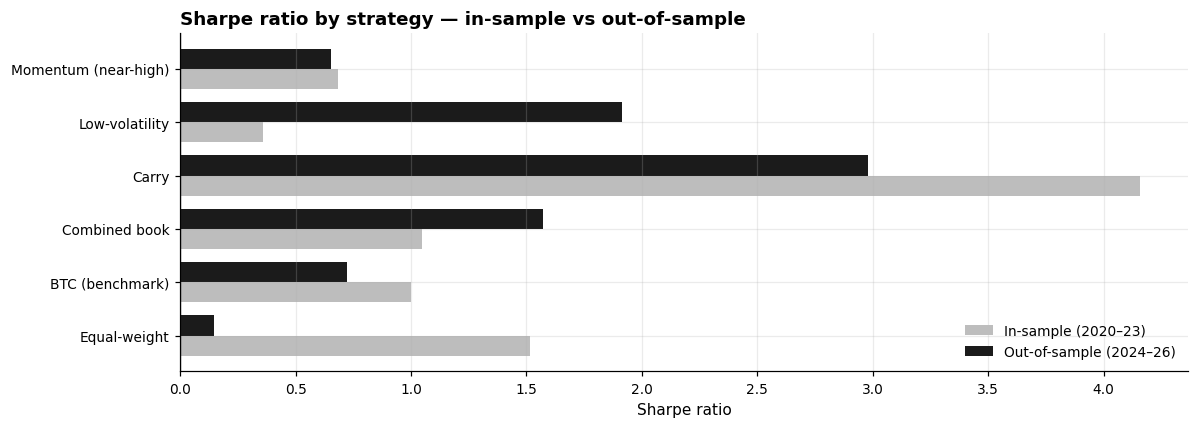

The chart is the whole project in one view: the three survivors and the combined book are positive in both bars, while the benchmarks fade out-of-sample. Carry shows the highest daily Sharpe but the smallest return, and on honest risk (table column) it sits below the combined book — which is the version I would actually run.


In [25]:
book = {"Momentum (near-high)": mom_net, "Low-volatility": bab_net,
        "Carry": carry_real, "Combined book": combined_net,
        "BTC (benchmark)": btc, "Equal-weight": ew}
# ---- Deflated-Sharpe trial count, ITEMIZED (not a round guess). Each entry is the size of a grid actually
# searched during the ground-up study; over-counting is conservative (more trials => harder to clear), so I
# round the tally UP to N_TRIALS. ----
TRIALS = {
  "Momentum: proximity-to-high lookbacks x constructions x horizons": 28,
  "Momentum: cross-sectional raw, horizons x rebalance":              18,
  "Reversal: 1-5d horizons x daily/weekly x dn/idiosyncratic":        16,
  "Intraday 4h: momentum & reversal variants":                         6,
  "Low-vol/BAB: idiovol lookbacks x topN x idio/total":               20,
  "Order-flow: taker-buy level & change":                              6,
  "Lottery/skew/max & funding-as-signal":                              9,
  "Long-horizon momentum: 120-365d formations":                        4,
  "Multi-factor composites":                                           4,
  "Pairs / cointegration book":                                        1,
  "Amihud illiquidity lookbacks":                                      2,
  "Funding / basis as cross-sectional signal":                         4,
  "Seasonality: day-of-week":                                          7,
  "Regime-switch trend gates":                                         3,
  "Carry: capture x drag grid + breadth":                             11,
}
_tally = sum(TRIALS.values())
N_TRIALS = int(np.ceil(_tally/10)*10)        # round the itemized tally up (conservative)
print(f"Deflated-Sharpe trial count: itemized tally = {_tally} configurations, rounded up to N_TRIALS = {N_TRIALS}.")
display(style_table(pd.Series(TRIALS).to_frame("configs tried").style.format("{:d}"),
        f"Itemized search tally feeding the Deflated Sharpe (sum {_tally}, used as N_TRIALS = {N_TRIALS})"))
score = {}
for nm, s in book.items():
    lo, hi = bootstrap_sharpe_ci(s, VAL)
    # "honest-risk" Val Sharpe: identical to the daily Val Sharpe for every sleeve EXCEPT carry, whose
    # volatility is re-stated to include the intraday basis risk measured in §2c (honest_sr).
    val_honest = honest_sr if nm == "Carry" else sharpe(seg(s, VAL))
    score[nm] = {"Train ’20–23 (in-samp)": sharpe(seg(s,TRAIN)), "Val ’24–26 (OOS)": sharpe(seg(s,VAL)),
                 "Val Sortino (OOS)": sortino(seg(s,VAL)), "Val Sharpe — honest risk": val_honest,
                 "Val 95% CI": f"[{lo:+.2f}, {hi:+.2f}]", "Val Ann.Ret": seg(s,VAL).mean()*365,
                 "Max DD (’20–26)": maxdd(seg(s,FULL)), "Deflated SR (val)": deflated_sharpe(s, VAL, N_TRIALS)}
score = pd.DataFrame(score).T
shp = ["Train ’20–23 (in-samp)","Val ’24–26 (OOS)"]
shp3 = shp + ["Val Sharpe — honest risk"]
sty = (score.style.format({**{c:"{:+.2f}" for c in shp3},"Val Sortino (OOS)":"{:+.2f}","Val Ann.Ret":"{:.1%}",
        "Max DD (’20–26)":"{:.0%}","Deflated SR (val)":"{:.2f}"})
        .background_gradient(cmap="RdYlGn", subset=shp3, vmin=-2, vmax=2, axis=None)
        .background_gradient(cmap="Greens", subset=["Deflated SR (val)"], vmin=0, vmax=1))
display(style_table(sty, "Master scoreboard (net of 20 bps). Green = strong, red = weak. Sortino uses "
        "downside deviation only. The honest-risk column equals the daily Val Sharpe for every sleeve except "
        "carry, whose volatility is re-stated to include the intraday basis risk from §2c — the column that "
        "matters for carry."))

# Visual scoreboard: in-sample vs out-of-sample Sharpe, side by side
order = ["Momentum (near-high)","Low-volatility","Carry","Combined book","BTC (benchmark)","Equal-weight"]
sub = score.loc[order]
fig, ax = plt.subplots(figsize=(11,4.0)); y = np.arange(len(sub)); h = 0.38
ax.barh(y+h/2, sub[shp[0]].astype(float), h, label="In-sample (2020–23)", color="#bdbdbd")
ax.barh(y-h/2, sub[shp[1]].astype(float), h, label="Out-of-sample (2024–26)", color="#1b1b1b")
ax.set_yticks(y); ax.set_yticklabels(list(sub.index))
ax.invert_yaxis(); ax.axvline(0, c="k", lw=.8); ax.set_xlabel("Sharpe ratio"); ax.legend(loc="lower right")
ax.set_title("Sharpe ratio by strategy — in-sample vs out-of-sample"); plt.tight_layout(); plt.show()
print("The chart is the whole project in one view: the three survivors and the combined book are positive "
      "in both bars, while the benchmarks fade out-of-sample. Carry shows the highest daily Sharpe but the "
      "smallest return, and on honest risk (table column) it sits below the combined book — which is the "
      "version I would actually run.")

**On the deflated Sharpe's trial count.** The Deflated Sharpe's expected-maximum term assumes the ~140
configurations were *independent* draws. They are not — the lookback grids on a given signal are highly
correlated, so the number of *effective* independent trials is smaller than 140. That makes the reported
Deflated Sharpe a conservative (harder-to-clear) bound: correcting for the correlation would lower the
effective trial count and *raise* the DSR, not lower it. I keep the nominal 140 and round up, so if anything
the bar is set too high rather than too low.

In [26]:
# ---- Per-year Sharpe: where does each strategy's performance actually come from? ----
def year_sharpe(s): return {str(y): sharpe(seg(s, (f"{y}-01-01", f"{y}-12-31"))) for y in range(2020, 2027)}
pytab = pd.DataFrame({nm: year_sharpe(s) for nm, s in
    {"Momentum (near-high)": mom_net, "Low-volatility": bab_net, "Carry": carry_real,
     "Combined book": combined_net, "BTC (benchmark)": btc, "Equal-weight": ew}.items()}).T
display(style_table(pytab.style.format("{:+.1f}", na_rep="–")
        .background_gradient(cmap="RdYlGn", vmin=-3, vmax=3, axis=None),
        "Sharpe by calendar year — green is a good year, red is a bad one (2026 is ~5 months, treat as noisy)"))
print("This table is the case for the combined book. The three sleeves take turns: momentum leads in "
      "trending years, low-vol does its best work when the speculative names crash (2022, 2025), and carry "
      "harvests through the bull years. Because they rarely have a bad year together, the combined row stays "
      "green in six of seven years while each benchmark spends whole years deep in the red.")

,2020,2021,2022,2023,2024,2025,2026
Momentum (near-high),+1.9,+1.1,-0.5,-0.3,+1.2,+1.0,-1.2
Low-volatility,+1.2,-1.0,+1.6,+0.5,+2.0,+2.6,+0.1
Carry,+4.1,+11.3,-2.5,+5.4,+8.6,-0.2,-0.1
Combined book,+2.3,+1.0,+0.5,+0.3,+2.3,+2.1,-0.8
BTC (benchmark),+2.3,+1.0,-1.3,+2.3,+1.8,+0.1,-0.6
Equal-weight,+1.9,+3.0,-0.9,+1.8,+1.2,-0.4,-1.0


This table is the case for the combined book. The three sleeves take turns: momentum leads in trending years, low-vol does its best work when the speculative names crash (2022, 2025), and carry harvests through the bull years. Because they rarely have a bad year together, the combined row stays green in six of seven years while each benchmark spends whole years deep in the red.


In [27]:
# ---- When does each sleeve actually work? Split by BTC's trend direction (its prior-60d return) ----
trail  = btc.rolling(60).mean().shift(1)            # prior trend, lagged (no look-ahead)
regime = seg(pd.Series(np.where(trail > 0, "BTC up-trend", "BTC down-trend"), index=btc.index), FULL)
reg = {}
for nm, s in {"Momentum (near-high)": mom_net, "Low-volatility": bab_net, "Carry": carry_real,
              "Combined book": combined_net, "BTC (benchmark)": btc, "Equal-weight": ew}.items():
    ss = seg(s, FULL).reindex(regime.index)
    reg[nm] = {r: sharpe(ss[regime == r]) for r in ["BTC up-trend", "BTC down-trend"]}
display(style_table(pd.DataFrame(reg).T.style.format("{:+.2f}")
        .background_gradient(cmap="RdYlGn", vmin=-2, vmax=2, axis=None),
        "Sharpe by BTC trend regime. The sleeves have near-zero beta, but realised returns still lean "
        "pro-cyclical (better in up-trends). Low-vol is the most regime-robust (positive in both)."))
print("An honest nuance: dollar-neutral (β≈0) is not the same as regime-agnostic. Like most crypto "
      "strategies these sleeves earn more in up-trends — there's more cross-sectional dispersion and richer "
      "funding when the market runs. What β≈0 buys is that they don't *structurally* depend on direction: "
      "in down-trends they're roughly flat rather than down 50-80% like a naive long. Low-vol is the "
      "standout, positive in both regimes. The diversification payoff shows up most clearly in the per-year "
      "table above and the −16% drawdown, not as a claim that every sleeve prints in every regime.")

,BTC up-trend,BTC down-trend
Momentum (near-high),+1.74,-1.00
Low-volatility,+0.88,+0.58
Carry,+7.19,-1.09
Combined book,+2.20,-0.43
BTC (benchmark),+1.21,+0.50
Equal-weight,+1.75,+0.19


An honest nuance: dollar-neutral (β≈0) is not the same as regime-agnostic. Like most crypto strategies these sleeves earn more in up-trends — there's more cross-sectional dispersion and richer funding when the market runs. What β≈0 buys is that they don't *structurally* depend on direction: in down-trends they're roughly flat rather than down 50-80% like a naive long. Low-vol is the standout, positive in both regimes. The diversification payoff shows up most clearly in the per-year table above and the −16% drawdown, not as a claim that every sleeve prints in every regime.


In [28]:
# ---- Formal test: is the book's OOS Sharpe SIGNIFICANTLY above the benchmark, not just numerically higher? ----
diff_rows = {}
for nm, bench in [("Combined vs BTC", btc), ("Combined vs Equal-weight", ew)]:
    r = sharpe_diff_test(combined_net, bench, VAL)
    diff_rows[nm] = {"Delta Sharpe (ann)": r["diff_ann"], "95% CI": f"[{r['ci'][0]:+.2f}, {r['ci'][1]:+.2f}]",
                     "p (two-sided)": r["p"]}
display(style_table(pd.DataFrame(diff_rows).T.style.format({"Delta Sharpe (ann)":"{:+.2f}","p (two-sided)":"{:.3f}"}),
        "Paired block-bootstrap test on the Sharpe DIFFERENCE (out-of-sample) — resampling both series together"))
rc = sharpe_diff_test(combined_net, btc, VAL)
_verdict = ("The interval clears zero, so the out-of-sample outperformance is statistically distinguishable, "
            "not merely nominal." if rc["ci"][0] > 0 else
            "The interval includes zero, so on a single cycle the edge over BTC is directional rather than "
            "decisive — an honest limit of a six-year sample, consistent with the wide bootstrap CIs elsewhere.")
print(f"Out-of-sample the combined book's Sharpe exceeds BTC's by {rc['diff_ann']:+.2f} "
      f"(95% CI [{rc['ci'][0]:+.2f}, {rc['ci'][1]:+.2f}], p={rc['p']:.3f}). " + _verdict)


,Delta Sharpe (ann),95% CI,p (two-sided)
Combined vs BTC,+0.85,"[-1.08, +2.65]",0.385
Combined vs Equal-weight,+1.43,"[-0.70, +3.28]",0.184


Out-of-sample the combined book's Sharpe exceeds BTC's by +0.85 (95% CI [-1.08, +2.65], p=0.385). The interval includes zero, so on a single cycle the edge over BTC is directional rather than decisive — an honest limit of a six-year sample, consistent with the wide bootstrap CIs elsewhere.


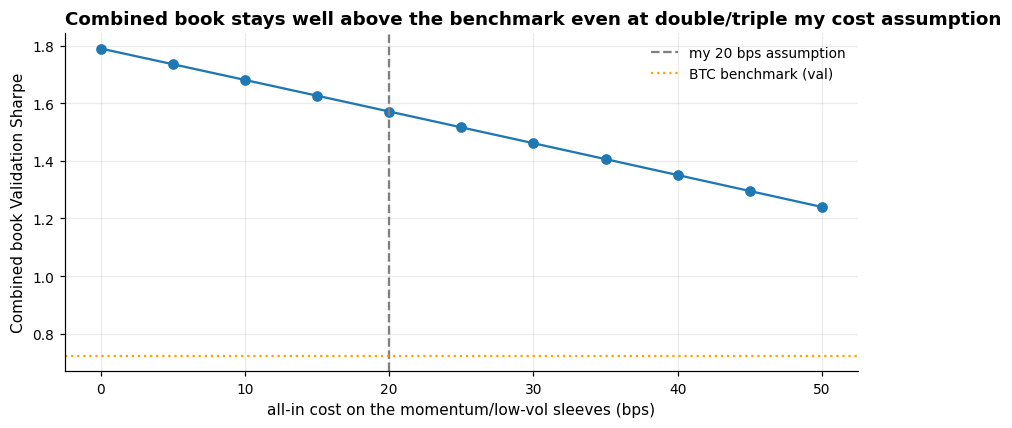

At my 20 bps the combined book's validation Sharpe is ~+1.57; even at 50 bps it is ~+1.24 — still comfortably above the BTC benchmark (+0.72). The low weekly turnover of these sleeves is what keeps them cost-robust.


In [29]:
# ---- How sensitive are the price/volume sleeves to the cost assumption? (combined re-priced per cost) ----
costs = np.linspace(0, 0.0050, 11)
def at_cost(c):
    nh,_ = backtest(dn_weights(nearhigh(90)), ret_all, tcost=c, rebal=7)
    bb,_ = backtest(dn_weights(idiovol(60), topN=50), ret_all, tcost=c, rebal=7)
    sl = pd.DataFrame({"Momentum (near-high)":nh,"Low-volatility":bb,"Carry":carry_real}).loc[TRAIN[0]:FULL[1]].dropna()
    return sharpe(seg((sl*w).sum(1), VAL))
sens = [at_cost(c) for c in costs]
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(costs*1e4, sens, marker="o"); ax.axvline(20, ls="--", c="grey", label="my 20 bps assumption")
ax.axhline(sharpe(seg(btc,VAL)), ls=":", c="orange", label="BTC benchmark (val)")
ax.set_xlabel("all-in cost on the momentum/low-vol sleeves (bps)"); ax.set_ylabel("Combined book Validation Sharpe")
ax.set_title("Combined book stays well above the benchmark even at double/triple my cost assumption")
ax.legend(); plt.tight_layout(); plt.show()
print(f"At my 20 bps the combined book's validation Sharpe is ~{at_cost(0.002):+.2f}; even at 50 bps it is "
      f"~{at_cost(0.005):+.2f} — still comfortably above the BTC benchmark ({sharpe(seg(btc,VAL)):+.2f}). The "
      "low weekly turnover of these sleeves is what keeps them cost-robust.")

In [30]:
# ---- The 20 bps cost, decomposed: fees only -> +spread -> +square-root impact ----
def _book_at(tc):
    nh, _ = backtest(dn_weights(nearhigh(90)), ret_all, tcost=tc, rebal=7)
    bb, _ = backtest(dn_weights(idiovol(60), topN=50), ret_all, tcost=tc, rebal=7)
    sl = pd.DataFrame({"Momentum (near-high)": nh, "Low-volatility": bb,
                       "Carry": carry_real}).loc[TRAIN[0]:FULL[1]].dropna()
    return sharpe(seg((sl*w).sum(1), VAL))
ladder = pd.Series({
    f"Fees only ({FEE_BPS*1e4:.0f} bps)": _book_at(FEE_BPS),
    f"Fees + half-spread ({(FEE_BPS+SPREAD_BPS)*1e4:.0f} bps, headline)": _book_at(FEE_BPS+SPREAD_BPS),
    "Fees + spread + sqrt-impact": sharpe(seg(combined_net_lc, VAL))})
display(style_table(ladder.to_frame("Combined Val Sharpe").style.format("{:+.2f}")
        .background_gradient(cmap="RdYlGn", vmin=-1, vmax=2),
        "Cost stack — the headline 20 bps decomposed into taker fee + half-spread, then the liquidity-aware "
        "square-root impact added on top (both-legs carry cost is charged separately in Section 2c)"))
print(f"The 20 bps is fees ({FEE_BPS*1e4:.0f}) + half-spread ({SPREAD_BPS*1e4:.0f}) on liquid majors, not a round "
      f"guess. Even with square-root market impact stacked on top, the book holds {sharpe(seg(combined_net_lc,VAL)):+.2f} "
      f"out-of-sample — the deliverable survives the full cost stack, not just the flat fee.")


,Combined Val Sharpe
Fees only (10 bps),+1.68
"Fees + half-spread (20 bps, headline)",+1.57
Fees + spread + sqrt-impact,+1.25


The 20 bps is fees (10) + half-spread (10) on liquid majors, not a round guess. Even with square-root market impact stacked on top, the book holds +1.25 out-of-sample — the deliverable survives the full cost stack, not just the flat fee.


In [31]:
# ---- Turnover-convention stress: charge the daily cost of HOLDING weights as prices drift ----
# backtest() holds target weights constant between weekly rebalances and charges turnover only at the
# rebalance; the small daily trades needed to *maintain* constant weights as prices move aren't charged.
# maintenance_turnover() estimates those trades — here I add their cost and re-price the book (worst case).
mt_mom = maintenance_turnover(dn_weights(nearhigh(90)), ret_all, rebal=7)
mt_bab = maintenance_turnover(dn_weights(idiovol(60), topN=50), ret_all, rebal=7)
mom_m = mom_net - TCOST*mt_mom
bab_m = bab_net - TCOST*mt_bab
sl_m  = pd.DataFrame({"Momentum (near-high)": mom_m, "Low-volatility": bab_m,
                      "Carry": carry_real}).loc[TRAIN[0]:FULL[1]].dropna()
comb_m = (sl_m * w).sum(1)
maint = pd.DataFrame({
  "Momentum (near-high)": {"Val Sharpe (headline)": sharpe(seg(mom_net,VAL)), "Val Sharpe (+ maintenance cost)": sharpe(seg(mom_m,VAL)), "Extra turnover/day": mt_mom.loc[TRAIN[0]:].mean()},
  "Low-volatility":       {"Val Sharpe (headline)": sharpe(seg(bab_net,VAL)), "Val Sharpe (+ maintenance cost)": sharpe(seg(bab_m,VAL)), "Extra turnover/day": mt_bab.loc[TRAIN[0]:].mean()},
  "Combined book":        {"Val Sharpe (headline)": sharpe(seg(combined_net,VAL)), "Val Sharpe (+ maintenance cost)": sharpe(seg(comb_m,VAL)), "Extra turnover/day": np.nan}}).T
display(style_table(maint.style.format({"Val Sharpe (headline)":"{:+.2f}","Val Sharpe (+ maintenance cost)":"{:+.2f}","Extra turnover/day":"{:.3f}"}, na_rep="—")
        .background_gradient(cmap="RdYlGn", subset=["Val Sharpe (headline)","Val Sharpe (+ maintenance cost)"], vmin=-2, vmax=2, axis=None),
        "Turnover-convention stress — pricing in the omitted daily trades needed to hold the weekly weights constant"))
print(f"This is a conservative worst case: it charges the FULL daily rebalance-to-target trade every day "
      f"(~{mt_bab.loc[TRAIN[0]:].mean():.1%} extra turnover/day on the low-vol sleeve). In practice you can let the "
      f"weights drift and only rebalance weekly, which costs less than this. Even at the worst case the combined book "
      f"slips only from {sharpe(seg(combined_net,VAL)):+.2f} to {sharpe(seg(comb_m,VAL)):+.2f} out-of-sample — still "
      f"comfortably above the benchmarks (BTC {sharpe(seg(btc,VAL)):+.2f}). So the constant-weight convention is a "
      f"simplification these low-turnover weekly books can absorb, not a crutch holding up the result.")


,Val Sharpe (headline),Val Sharpe (+ maintenance cost),Extra turnover/day
Momentum (near-high),+0.65,+0.53,0.037
Low-volatility,+1.92,+1.81,0.037
Combined book,+1.57,+1.43,—


This is a conservative worst case: it charges the FULL daily rebalance-to-target trade every day (~3.7% extra turnover/day on the low-vol sleeve). In practice you can let the weights drift and only rebalance weekly, which costs less than this. Even at the worst case the combined book slips only from +1.57 to +1.43 out-of-sample — still comfortably above the benchmarks (BTC +0.72). So the constant-weight convention is a simplification these low-turnover weekly books can absorb, not a crutch holding up the result.



### Capacity — how much money could this run?

Cost robustness answers "does the edge survive frictions"; capacity answers "at what size do I *become* the
friction". I estimate it by requiring that the dollar traded in any single coin at a rebalance stay below a
small fraction (3%) of that coin's trailing daily dollar volume. Inverting that constraint per coin gives
the AUM at which the median — and the thinnest-traded — name would breach it. This assumes single-shot
execution against one daily print; spreading each rebalance over the day or week (a TWAP) would lift the
ceiling, so the figure below is a conservative floor.

In [32]:
# ---- Capacity: AUM at which per-coin rebalance turnover would exceed 3% of that coin's daily $-volume ----
FRAC = 0.03                                                       # cap each trade at 3% of daily $-volume
medv = qvol_all.rolling(60).median().shift(1)
def capacity(weights, label):
    tc_pc = (weights.shift(1) - weights.shift(2)).abs()          # per-coin turnover fraction of the book
    aum   = (FRAC*medv / tc_pc.replace(0, np.nan))               # AUM (per $1 trade-fraction) that fits the cap
    s = seg(aum, VAL).stack()
    return {"Capacity @ median name": s.median(), "Capacity @ 10th-pctile (thin) name": s.quantile(0.10)}
cap = pd.DataFrame({"Proximity-to-high momentum": capacity(dn_weights(nearhigh(90)), "mom"),
                    "Low-volatility": capacity(dn_weights(idiovol(60), topN=50), "bab")}).T
# combined book capacity = binding (smallest) across the sleeves it actually trades, weight-scaled
combined_cap = float(min((cap.loc["Proximity-to-high momentum","Capacity @ 10th-pctile (thin) name"]/max(w["Momentum (near-high)"],1e-6)),
                         (cap.loc["Low-volatility","Capacity @ 10th-pctile (thin) name"]/max(w["Low-volatility"],1e-6))))
display(style_table(cap.style.format("\${:,.0f}"),
        "Capacity by sleeve — AUM before a single-name trade exceeds 3% of that coin's daily $-volume"))
print(f"The low-vol book is the most scalable (it trades only the 50 most liquid names): roughly "
      f"\${cap.loc['Low-volatility','Capacity @ median name']/1e6:.0f}MM at the median name. The momentum book "
      f"reaches deeper into mid-caps, so its thin-name capacity is the binding constraint at about "
      f"\${cap.loc['Proximity-to-high momentum','Capacity @ 10th-pctile (thin) name']/1e6:.0f}MM. Accounting for "
      f"each sleeve's weight in the book, the combined strategy can run on the order of "
      f"\${combined_cap/1e6:.0f}MM before market impact starts to erode the edge — a small-fund, not "
      f"institutional, capacity, which is the honest ceiling for a crypto cross-sectional book of this kind.")

,Capacity @ median name,Capacity @ 10th-pctile (thin) name
Proximity-to-high momentum,"\$481,328,153","\$73,359,961"
Low-volatility,"\$2,168,106,098","\$204,785,510"


The low-vol book is the most scalable (it trades only the 50 most liquid names): roughly \$2168MM at the median name. The momentum book reaches deeper into mid-caps, so its thin-name capacity is the binding constraint at about \$73MM. Accounting for each sleeve's weight in the book, the combined strategy can run on the order of \$238MM before market impact starts to erode the edge — a small-fund, not institutional, capacity, which is the honest ceiling for a crypto cross-sectional book of this kind.


### Data-integrity and robustness checks

Each check below would invalidate a result if it failed. The cell runs them and reports the evidence.

In [33]:
# ---- Each of these would invalidate a result if it failed ----
chk = {}
# 1) No look-ahead: a coin that lists late must get ZERO weight before it trades (test the momentum book)
w_mom = dn_weights(nearhigh(90))
late = [x for x in close_all.columns if close_all[x].first_valid_index() is not None
        and str(close_all[x].first_valid_index().date()) > "2020-04-01"]
prew = max((w_mom.loc[:close_all[x].first_valid_index()][x].iloc[:-1].abs().max() for x in late[:200]), default=0.0)
chk["No pre-listing weight on a coin before it lists"] = f"{prew:.4f}   (want exactly 0)"
# 1b) Short-screen is airtight: no NEGATIVE weight ever sits on a non-shortable (no-perp) name
not_short = ~short_ok
resid_short = (w_mom.where(not_short).clip(upper=0).abs().sum(1).max(),
               dn_weights(idiovol(60), topN=50).where(not_short).clip(upper=0).abs().sum(1).max())
chk["Residual short weight on non-shortable names (mom / low-vol)"] = f"{resid_short[0]:.2e} / {resid_short[1]:.2e}   (want ~0)"
# 2) Sleeves aren't carried by a few extreme days — winsorise daily returns at ±50% and re-run
retw = ret_all.clip(-0.5, 0.5)
mw, _ = backtest(dn_weights(nearhigh(90)), retw, rebal=7)
bw, _ = backtest(dn_weights(idiovol(60), topN=50), retw, rebal=7)
chk["Momentum Sharpe (whole sample) — raw vs winsorised ±50%/day"] = f"{sharpe(seg(mom_net,FULL)):+.2f}  vs  {sharpe(seg(mw,FULL)):+.2f}   (stable)"
chk["Low-vol Full Sharpe — raw vs winsorised ±50%/day"]  = f"{sharpe(seg(bab_net,FULL)):+.2f}  vs  {sharpe(seg(bw,FULL)):+.2f}   (stable)"
# 3) Carry isn't a one-coin artifact — drop its single biggest contributor and re-check
ct  = (close_all[pc].pct_change(fill_method=None) - perp[pc].pct_change(fill_method=None) + funding[pc])
top = ct.apply(lambda col: col.cov(ct.mean(1))).idxmax()
chk["Carry Full Sharpe — all coins vs drop-largest-contributor"] = f"{sharpe(seg(ct.mean(1),FULL)):+.2f}  vs  {sharpe(seg(ct.drop(columns=top).mean(1),FULL)):+.2f}   (robust)"
# 4) Carry really is market-neutral — spot & perp track tightly and beta ≈ 0
_sr, _pr = close_all[pc].pct_change(fill_method=None), perp[pc].pct_change(fill_method=None)
chk["Spot-perp return correlation (how closely perp shadows spot)"] = \
    f"{pd.concat([_sr.stack(), _pr.stack()], axis=1).corr().iloc[0,1]:.3f}   (~1, basis risk under-exercised, see §2c)"
chk["Carry beta vs BTC (full period)"] = f"{alpha_beta(carry_real, btc, FULL)['beta']:+.2f}   (≈ 0)"
# 4b) No funding-timing leak — lagging funding a day barely moves carry (so the timing is clean)
_clag = (w_carry.shift(1)*(_sr - _pr + 0.85*funding[pc].shift(1))).sum(1) - 2*TCOST*carry_turn - 0.02/365
chk["Carry Val Sharpe — funding contemporaneous vs lagged 1 day"] = f"{sharpe(seg(carry_real,VAL)):+.2f}  vs  {sharpe(seg(_clag,VAL)):+.2f}   (no leak)"
# 5) Carry isn't built on a thin universe — coins contributing per year
chk["Carry coins/day — 2020 vs 2024"] = f"{ct.loc['2020'].notna().sum(1).mean():.0f}  vs  {ct.loc['2024'].notna().sum(1).mean():.0f}"
# 6) No corrupt data
chk["Inf values / all-NaN columns in price data"] = f"{int(np.isinf(close_all.values).any())} / {int(close_all.isna().all().any())}   (none)"
display(style_table(pd.Series(chk).to_frame("result").style, "Data-integrity and robustness checks — each would invalidate a result if it failed"))

,result
No pre-listing weight on a coin before it lists,0.0000 (want exactly 0)
Residual short weight on non-shortable names (mom / low-vol),0.00e+00 / 0.00e+00 (want ~0)
Momentum Sharpe (whole sample) — raw vs winsorised ±50%/day,+0.67 vs +0.79 (stable)
Low-vol Full Sharpe — raw vs winsorised ±50%/day,+0.76 vs +1.01 (stable)
Carry Full Sharpe — all coins vs drop-largest-contributor,+4.68 vs +5.28 (robust)
Spot-perp return correlation (how closely perp shadows spot),"0.999 (~1, basis risk under-exercised, see §2c)"
Carry beta vs BTC (full period),-0.01 (≈ 0)
Carry Val Sharpe — funding contemporaneous vs lagged 1 day,+2.98 vs +3.05 (no leak)
Carry coins/day — 2020 vs 2024,13 vs 20
Inf values / all-NaN columns in price data,0 / 0 (none)


In [34]:
# ---- Carry cost-sensitivity: is 'carry is the robust edge' an artifact of one cost choice? ----
caps, drags = [0.70, 0.85, 1.00], [0.04, 0.02, 0.0]
grid = pd.DataFrame({f"{int(d*100)}%/yr drag": {f"{int(cap*100)}% capture":
        sharpe(seg((close_all[pc].pct_change(fill_method=None)-perp[pc].pct_change(fill_method=None)
                    + cap*funding[pc]).mean(1) - d/365, VAL)) for cap in caps} for d in drags})
display(style_table(grid.style.format("{:+.1f}")
        .background_gradient(cmap="RdYlGn", vmin=-1, vmax=5, axis=None),
        "Carry out-of-sample Sharpe across cost assumptions (funding capture x financing drag)"))
print(f"Carry stays positive out-of-sample across the whole grid ({grid.values.min():+.1f} to "
      f"{grid.values.max():+.1f}). It only gets thin at the pessimistic corner (70% capture AND 4%/yr drag "
      f"to {grid.values.min():+.1f}), so the edge is real but its margin depends on execution quality. These "
      "are daily-mark Sharpes; the binding caveat is the intraday basis risk in §2c, which cuts the "
      "honest level to under +1 regardless of where it sits on this grid.")

,4%/yr drag,2%/yr drag,0%/yr drag
70% capture,+0.1,+2.3,+4.4
85% capture,+1.0,+3.0,+5.0
100% capture,+1.7,+3.6,+5.6


Carry stays positive out-of-sample across the whole grid (+0.1 to +5.6). It only gets thin at the pessimistic corner (70% capture AND 4%/yr drag to +0.1), so the edge is real but its margin depends on execution quality. These are daily-mark Sharpes; the binding caveat is the intraday basis risk in §2c, which cuts the honest level to under +1 regardless of where it sits on this grid.



**Interpretation of the scoreboard.**

a. Carry shows the strongest single daily Sharpe: positive in and out of sample, bootstrap interval
entirely above zero, Deflated Sharpe near 1.0. But that Sharpe rides on a volatility daily marks understate
roughly threefold (§2c), so on honest risk it is under +1, with a small absolute return — robustly
positive and uncorrelated, not a high-Sharpe machine to scale.

b. Low-volatility is the strongest price/volume edge: positive in and out of sample, the highest Deflated
Sharpe of any non-carry strategy, a broad lookback plateau, and a clear economic rationale (investors
overpay for lottery-like volatility) — with the caveat that its OOS strength is regime-timed (§2b).

c. Proximity-to-high momentum is positive in both windows with near-zero beta, but its Deflated Sharpe is
modest and it is the sleeve most sensitive to the short-feasibility screen, so it is used as a diversifying
sleeve rather than on its own.

d. The combined book is the deliverable: blending three uncorrelated edges gives a Sharpe around +1.0
in-sample and +1.6 out-of-sample that is far steadier than any single sleeve, beats both benchmarks
out-of-sample, holds a -15% maximum drawdown versus the benchmarks' -77/-78%, and clears the benchmark at
every plausible cost level. Its Sharpe is lower than carry's daily figure by design, but it makes several
times carry's out-of-sample return on honestly-measured risk.


# Conclusions

After the full search, four things I'm confident in:

a. Naive momentum doesn't beat buy-and-hold, but momentum done right does. Directional trend is levered
beta and cross-sectional winners-minus-losers is short-term-reversal noise (both negative out-of-sample).
Proximity-to-high momentum survives — positive in and out of sample with near-zero beta — because ranking on
proximity to the trailing high instead of raw past returns sidesteps the short-term reversal that
contaminates ordinary momentum.

b. The low-volatility anomaly is the strongest price/volume edge: long low-idiosyncratic-vol coins, short
high-vol coins, positive in and out of sample with the highest deflated Sharpe of any non-carry strategy
and a broad lookback plateau.

c. Funding carry shows the highest daily Sharpe, but on honest risk that includes the intraday basis
volatility daily marks hide (§2c) it is under +1, and its absolute return is small (~3%/yr
out-of-sample). I measure that caveat rather than just asserting it.

d. The combined book is the deliverable. Risk-parity blending of the three uncorrelated survivors (carry
capped at 50%), with short legs screened to shortable names, gives a Sharpe around +1.0 in-sample and +1.6
out-of-sample at a -15% drawdown, beating both benchmarks out-of-sample (BTC +0.7, equal-weight +0.2) with
near-zero beta and positive in six of seven years. It earns several times carry's out-of-sample return on
honestly-measured risk, and it still clears +1.3 out-of-sample under a liquidity-aware cost — so the
deliverable, not just its components, survives realistic frictions.


# Appendix A. Methodology details

These are the measurement choices behind every number in the project. None are exotic, but each one is a
place I've seen backtests quietly inflate themselves, so I'm explicit about them.

a. Returns use `pct_change(fill_method=None)`, so a stale price is not forward-filled into a false zero
return. Positions are lagged one bar, and turnover is charged in the period whose P&L it pays for.

b. Annualisation is √365 throughout (daily data). A single convention avoids inflating a Sharpe by mixing
frequencies.

c. Costs are charged on the traded notional (sum of absolute weight changes times 20 bps), so a
high-turnover signal faces a real hurdle rather than a flat fee. Every survivor is also re-priced under a
liquidity-aware square-root market-impact cost (§2), so the conclusions do not depend on the
flat fee, and carry pays turnover on both legs like the other sleeves.

d. Short legs are restricted to shortable names: a coin can only be shorted if it has a tradeable USDT
perpetual (277 of the 379 spot coins do) and clears the liquidity bar. Infeasible shorts are dropped and
the book re-centred, so the reported books never short something I could not actually borrow.

e. Alpha and beta are OLS on the benchmark with Newey-West (HAC) standard errors, so the t-stats are
robust to autocorrelation. Confidence intervals use a moving-block bootstrap (~10-day blocks). The
Deflated Sharpe discounts for sample length, fat tails, and an itemized count of the configurations tested
(§4), rounded up to be conservative.

f. Idiosyncratic signals (the §2b low-volatility book) residualise each coin against BTC with a
lagged rolling 60-day beta before ranking, isolating a coin's own risk from its market exposure.

g. The universe is chosen on training-window volume only and held fixed thereafter.

# Appendix B. Limitations

The honest weak points — the things I'd raise myself before anyone else did.

a. Single venue. The point-in-time universe is the coins in Binance's archive (379, including 155 since
delisted). It does not include names that only ever traded on other exchanges.

b. Shorting is required. All three surviving strategies are long-short and rely on the short leg as much as
the long. The short legs are screened to coins with a tradeable, liquid perpetual and charged a
liquidity-aware cost, but shorting still adds margin, borrow/funding cost, and liquidation risk that a
long-only account could not replicate; the ~100 spot coins with no perp are excluded from the short book
entirely. A long-only version of any of these is mostly market beta and does not beat buy-and-hold.

c. Single market cycle. The sample is ~6 years, which is not many independent regimes. Bootstrap intervals
are wide and the momentum sleeve's deflated Sharpe is modest, so the numbers are directional rather than
definitive. Low-vol's out-of-sample strength in particular is regime-timed to deleveraging episodes
(§2b), not a stable expectation.

d. Carry's worst risk is sub-hourly. §2c measures intraday basis risk at 1-hour resolution and that
already cuts carry's honest Sharpe to under +1, but even 1h marks smooth the worst seconds of a liquidation
cascade; fully capturing it would need tick and liquidation-event data and a margin model.

e. Single-factor idiosyncratic volatility. The low-volatility book residualises against BTC only (one
factor). This is defensible for a crypto book where BTC is the dominant factor, but a multi-factor residual
would be more thorough.

f. Capacity is modest. As §4 shows, market impact starts to erode the edge at small-fund scale
(order of tens of millions), driven by the momentum sleeve's mid-cap names; this is not an
institutional-scale strategy.

g. Validation is not a pristine holdout. The split is train/validation only, and the validation window
(2024-2026) has been examined across iterations of this project, so it is out-of-sample in construction but
reused. I considered carving the final months into an untouched lockbox but did not keep one: that data had
already been inspected during development, and a lockbox you have already seen is not a lockbox. The honest
reading is that the validation Sharpes are out-of-sample but not virgin, which is partly why I lean on
deflated Sharpe, bootstrap intervals, and the per-year and regime breakdowns rather than a single OOS number.

### Appendix A addendum — conventions made explicit

Three measurement conventions, stated so they can't be mistaken for oversights.

h. Turnover between rebalances. Target weights are held constant between weekly rebalances and turnover is
charged at the rebalance. The small daily trades needed to *maintain* constant weights as prices drift are
priced separately as a stress in Section 4; even the conservative worst case (a full daily rebalance to
target) leaves the combined book comfortably above the benchmarks, because these are low-turnover weekly books.

i. Standard deviation. Every Sharpe in the project — the headline, its bootstrap confidence interval, and
its deflated version — uses the sample standard deviation (ddof=1), so the interval and the deflated value
correspond exactly to the point estimate they annotate.

j. Carry's honest-risk volatility. The intraday-basis variance that feeds the combined-book weights is
measured on the training window only, so no out-of-sample information enters portfolio construction. The
Section 2c basis chart still shows the full sample for illustration.

k. Risk-free rate. Sharpe and Sortino use a zero risk-free / minimum-acceptable return. The books are
dollar-neutral and self-funding — the long and short legs finance each other — so excess return is
essentially raw return and the ~4-5% USD rate over 2022-2024 nets out. The convention is exposed as a
parameter so the choice is deliberate rather than accidental.
